In [ ]:
import pandas as pd
from run_all_task import get_mixed_dataset
from prepare_data import extract_gtcc, extract_mel_spectrogram, extract_mfcc, extract_lfcc, extract_cqcc
from omegaconf import OmegaConf
from ASV_dl_func import *

In [4]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [ ]:
config = OmegaConf.load("config.yaml")

la_metadata = config.datasets.LA.metadata
la_flac_folders = config.datasets.LA.flac
in_the_wild_dir = config.datasets.paths.in_the_wild_dir

In [ ]:
train_df, val_df, test_df = get_mixed_dataset(in_the_wild_dir, la_metadata, la_flac_folders)

In [ ]:
train_aug = add_dataAugmentation(train_df)

In [ ]:
feature_extractors_map = {
    'cqcc': extract_cqcc,
    'gtcc': extract_gtcc,
    'mel-spect': extract_mel_spectrogram,
    'mfcc': extract_mfcc,
    'lfcc': extract_lfcc
}
col_name = feature_extractors_map.keys

In [ ]:
train_df_prepared = extract_features(train_aug, feature_extractors_map)

   - Ekstrahuję: mel-spect


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1120 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 5120 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 14048 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 28014 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-1)]: Done 28522 out of 28522 | elapsed:   17.6s finished


In [ ]:
train_df_prepared = train_df_prepared.dropna(subset=col_name)

In [ ]:

val_df = extract_features(val_df, feature_extractors_map)
val_df_prepared = val_df.dropna()

test_df = extract_features(test_df, feature_extractors_map)
test_df_prepared = test_df.dropna()

   - Ekstrahuję: mel-spect


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1248 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 4800 out of 4800 | elapsed:    1.3s finished


# Sprawdzenie zbalansowanai

In [ ]:
train_df_noscale = balance_func(train_df_prepared, col_name='label')

Zbilansowane dane: true=8429, false=8429


In [ ]:
val_df_noscale = balance_func(val_df_prepared, col_name='label')

Zbilansowane dane: true=1329, false=1329


# Siec rezydualne

In [ ]:
feature_cols = feature_extractors_map.keys()


========== Trening z Adam_CrossEntropyLoss_lr0.001_wd1e-05 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6414 | Train Acc: 0.6273 | Val Loss: 0.5159 | Val Acc: 0.7686
[cqcc] Epoch 2/100 | Train Loss: 0.6002 | Train Acc: 0.6853 | Val Loss: 0.5106 | Val Acc: 0.7731
[cqcc] Epoch 3/100 | Train Loss: 0.5931 | Train Acc: 0.6953 | Val Loss: 0.5218 | Val Acc: 0.7656
[cqcc] Epoch 4/100 | Train Loss: 0.5864 | Train Acc: 0.7068 | Val Loss: 0.4982 | Val Acc: 0.7728
[cqcc] Epoch 5/100 | Train Loss: 0.5780 | Train Acc: 0.7083 | Val Loss: 0.4901 | Val Acc: 0.7765
[cqcc] Epoch 6/100 | Train Loss: 0.5698 | Train Acc: 0.7122 | Val Loss: 0.4732 | Val Acc: 0.7758
[cqcc] Epoch 7/100 | Train Loss: 0.5624 | Train Acc: 0.7163 | Val Loss: 0.4769 | Val Acc: 0.7660
[cqcc] Epoch 8/100 | Train Loss: 0.5507 | Train Acc: 0.7189 | Val Loss: 0.4374 | Val Acc: 0.7874
[cqcc] Epoch 9/100 | Train Loss: 0.5391 | Train Acc: 0.7285 | Val Loss: 0.4387 | Val Acc: 0.7931
[cqcc] Epoch 10/100 | T

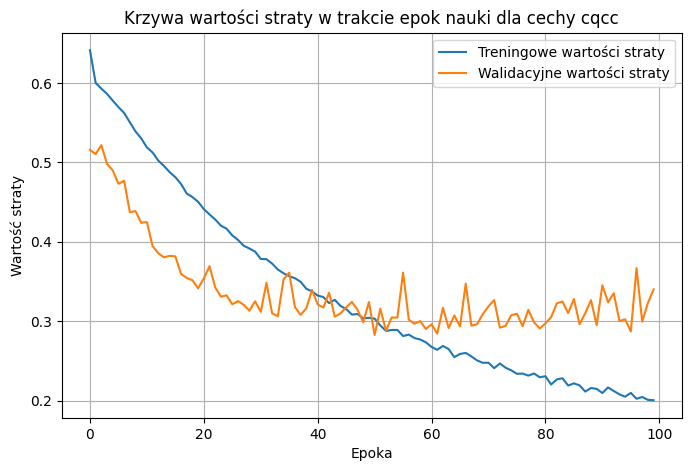

Final Accuracy: 0.8886 | F1 Score: 0.8869 | EER: 0.1136
Final Accuracy: 0.8815 | F1 Score: 0.8766 | EER: 0.1121
Zapisano modele i wyniki dla 'cqcc' → Adam_CrossEntropyLoss_lr0.001_wd1e-05
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.001_wd1e-05\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6450 | Train Acc: 0.6200 | Val Loss: 0.5246 | Val Acc: 0.7720
[gtcc] Epoch 2/100 | Train Loss: 0.6053 | Train Acc: 0.6603 | Val Loss: 0.5066 | Val Acc: 0.7701
[gtcc] Epoch 3/100 | Train Loss: 0.5933 | Train Acc: 0.6659 | Val Loss: 0.4858 | Val Acc: 0.7784
[gtcc] Epoch 4/100 | Train Loss: 0.5875 | Train Acc: 0.6678 | Val Loss: 0.4897 | Val Acc: 0.7822
[gtcc] Epoch 5/100 | Train Loss: 0.5830 | Train Acc: 0.6713 | Val Loss: 0.4804 | Val Acc: 0.7754
[gtcc] Epoch 6/100 | Train Loss: 0.5780 | Train Acc: 0.6795 | Val Loss: 0.4791 | Val Acc: 0.7837
[gtcc] Epoch 7/100 | Train Loss: 0.5734 | Train Acc: 0.6783 | Val Loss: 0.4653 | Val Acc: 0.7852


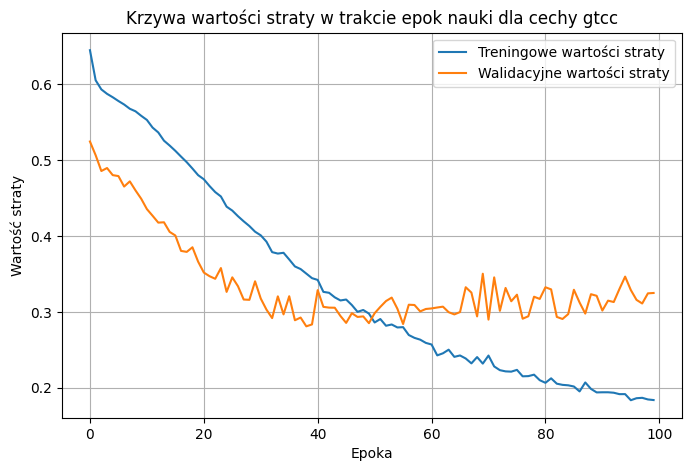

Final Accuracy: 0.8871 | F1 Score: 0.8839 | EER: 0.1144
Final Accuracy: 0.8834 | F1 Score: 0.8772 | EER: 0.1242
Zapisano modele i wyniki dla 'gtcc' → Adam_CrossEntropyLoss_lr0.001_wd1e-05
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.001_wd1e-05\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6306 | Train Acc: 0.6389 | Val Loss: 0.4956 | Val Acc: 0.7761
[mel-spect] Epoch 2/100 | Train Loss: 0.5883 | Train Acc: 0.6711 | Val Loss: 0.4675 | Val Acc: 0.7803
[mel-spect] Epoch 3/100 | Train Loss: 0.5763 | Train Acc: 0.6701 | Val Loss: 0.4696 | Val Acc: 0.7803
[mel-spect] Epoch 4/100 | Train Loss: 0.5671 | Train Acc: 0.6745 | Val Loss: 0.4691 | Val Acc: 0.7750
[mel-spect] Epoch 5/100 | Train Loss: 0.5619 | Train Acc: 0.6725 | Val Loss: 0.4481 | Val Acc: 0.7859
[mel-spect] Epoch 6/100 | Train Loss: 0.5548 | Train Acc: 0.6790 | Val Loss: 0.4114 | Val Acc: 0.8198
[mel-spect] Epoch 7/100 | Train Loss: 0.5356 | Train Acc: 0.69

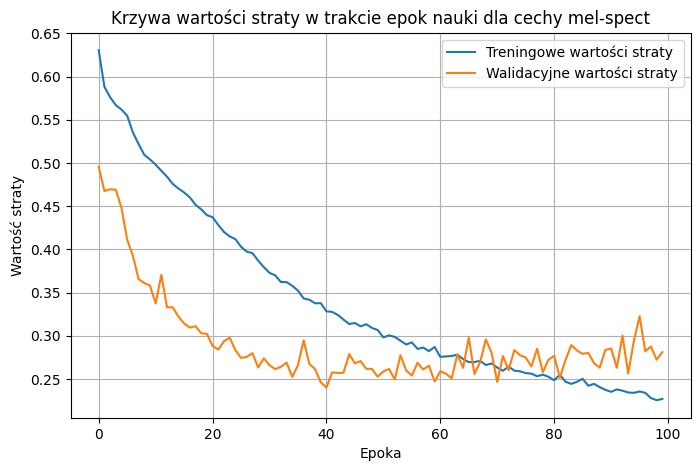

Final Accuracy: 0.9033 | F1 Score: 0.9033 | EER: 0.0971
Final Accuracy: 0.9146 | F1 Score: 0.9143 | EER: 0.0858
Zapisano modele i wyniki dla 'mel-spect' → Adam_CrossEntropyLoss_lr0.001_wd1e-05
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.001_wd1e-05\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6162 | Train Acc: 0.6590 | Val Loss: 0.5091 | Val Acc: 0.7765
[mfcc] Epoch 2/100 | Train Loss: 0.5918 | Train Acc: 0.6721 | Val Loss: 0.4854 | Val Acc: 0.7761
[mfcc] Epoch 3/100 | Train Loss: 0.5759 | Train Acc: 0.6760 | Val Loss: 0.4844 | Val Acc: 0.7788
[mfcc] Epoch 4/100 | Train Loss: 0.5666 | Train Acc: 0.6754 | Val Loss: 0.4543 | Val Acc: 0.7833
[mfcc] Epoch 5/100 | Train Loss: 0.5542 | Train Acc: 0.6792 | Val Loss: 0.4331 | Val Acc: 0.7878
[mfcc] Epoch 6/100 | Train Loss: 0.5392 | Train Acc: 0.6895 | Val Loss: 0.4303 | Val Acc: 0.7923
[mfcc] Epoch 7/100 | Train Loss: 0.5312 | Train Acc: 0.6940 | Val Loss: 0.3981 | V

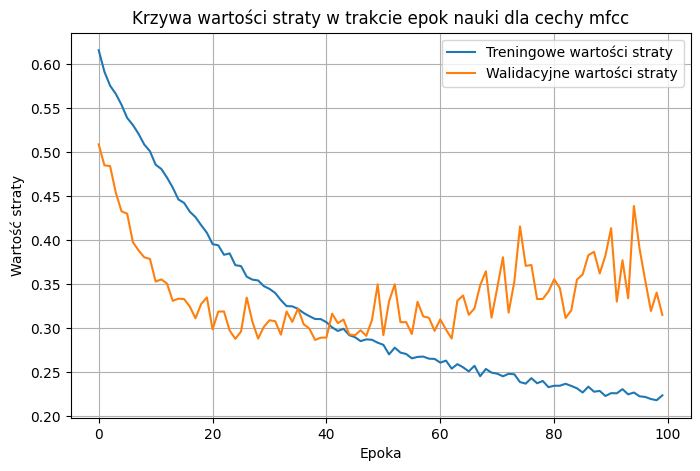

Final Accuracy: 0.8879 | F1 Score: 0.8887 | EER: 0.1106
Final Accuracy: 0.9041 | F1 Score: 0.9023 | EER: 0.1023
Zapisano modele i wyniki dla 'mfcc' → Adam_CrossEntropyLoss_lr0.001_wd1e-05
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.001_wd1e-05\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6247 | Train Acc: 0.6402 | Val Loss: 0.5154 | Val Acc: 0.7731
[lfcc] Epoch 2/100 | Train Loss: 0.5972 | Train Acc: 0.6702 | Val Loss: 0.5034 | Val Acc: 0.7807
[lfcc] Epoch 3/100 | Train Loss: 0.5900 | Train Acc: 0.6742 | Val Loss: 0.5099 | Val Acc: 0.7792
[lfcc] Epoch 4/100 | Train Loss: 0.5898 | Train Acc: 0.6757 | Val Loss: 0.4911 | Val Acc: 0.7871
[lfcc] Epoch 5/100 | Train Loss: 0.5812 | Train Acc: 0.6760 | Val Loss: 0.4696 | Val Acc: 0.7908
[lfcc] Epoch 6/100 | Train Loss: 0.5755 | Train Acc: 0.6787 | Val Loss: 0.4806 | Val Acc: 0.7931
[lfcc] Epoch 7/100 | Train Loss: 0.5702 | Train Acc: 0.6830 | Val Loss: 0.4672 | Val Acc: 0.7893


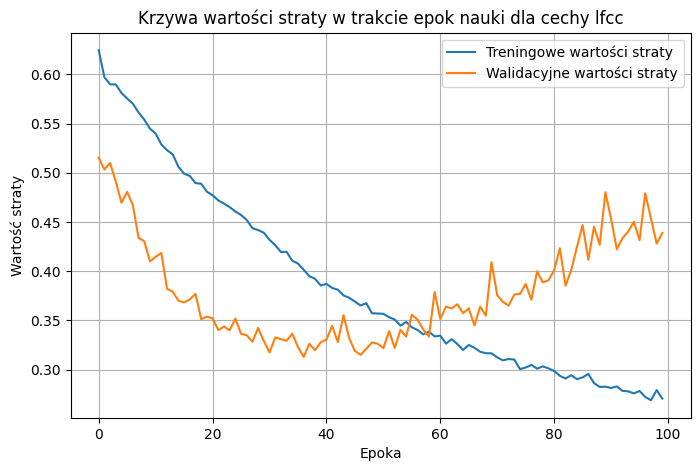

Final Accuracy: 0.8627 | F1 Score: 0.8580 | EER: 0.1407
Final Accuracy: 0.8600 | F1 Score: 0.8582 | EER: 0.1422
Zapisano modele i wyniki dla 'lfcc' → Adam_CrossEntropyLoss_lr0.001_wd1e-05
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.001_wd1e-05\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla Adam_CrossEntropyLoss_lr0.001_wd1e-05 ==========


========== Trening z Adam_CrossEntropyLoss_lr0.001_wd0.0001 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6437 | Train Acc: 0.6202 | Val Loss: 0.5239 | Val Acc: 0.7698
[cqcc] Epoch 2/100 | Train Loss: 0.6049 | Train Acc: 0.6702 | Val Loss: 0.5153 | Val Acc: 0.7667
[cqcc] Epoch 3/100 | Train Loss: 0.5949 | Train Acc: 0.6881 | Val Loss: 0.5018 | Val Acc: 0.7758
[cqcc] Epoch 4/100 | Train Loss: 0.5916 | Train Acc: 0.6962 | Val Loss: 0.5088 | Val Acc: 0.7761
[cqcc] Epoch 5/100 | Train Loss: 0.5893 | Train Acc: 0.6991 | Val Loss: 0.5097 | Val Acc: 0.7701
[cqcc] Epoch 6/100 | Train Loss: 0.5884 |

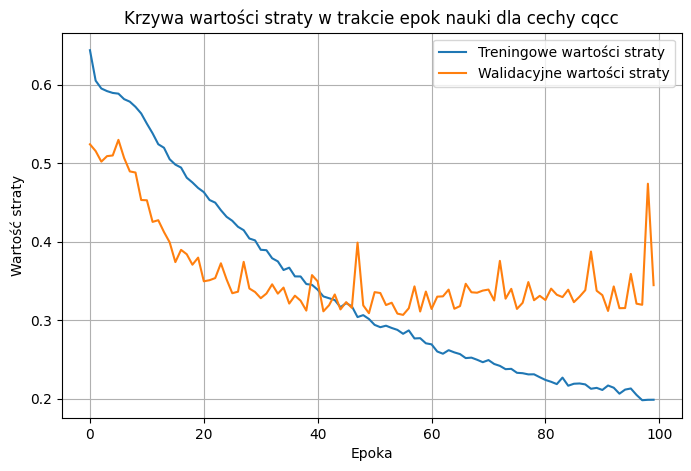

Final Accuracy: 0.8634 | F1 Score: 0.8592 | EER: 0.1317
Final Accuracy: 0.8672 | F1 Score: 0.8633 | EER: 0.1354
Zapisano modele i wyniki dla 'cqcc' → Adam_CrossEntropyLoss_lr0.001_wd0.0001
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.001_wd0.0001\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6378 | Train Acc: 0.6265 | Val Loss: 0.5190 | Val Acc: 0.7728
[gtcc] Epoch 2/100 | Train Loss: 0.6034 | Train Acc: 0.6646 | Val Loss: 0.5087 | Val Acc: 0.7784
[gtcc] Epoch 3/100 | Train Loss: 0.5979 | Train Acc: 0.6670 | Val Loss: 0.5018 | Val Acc: 0.7769
[gtcc] Epoch 4/100 | Train Loss: 0.5949 | Train Acc: 0.6635 | Val Loss: 0.5017 | Val Acc: 0.7750
[gtcc] Epoch 5/100 | Train Loss: 0.5901 | Train Acc: 0.6747 | Val Loss: 0.4832 | Val Acc: 0.7754
[gtcc] Epoch 6/100 | Train Loss: 0.5825 | Train Acc: 0.6739 | Val Loss: 0.4809 | Val Acc: 0.7731
[gtcc] Epoch 7/100 | Train Loss: 0.5791 | Train Acc: 0.6790 | Val Loss: 0.4833 | Val Acc: 0.786

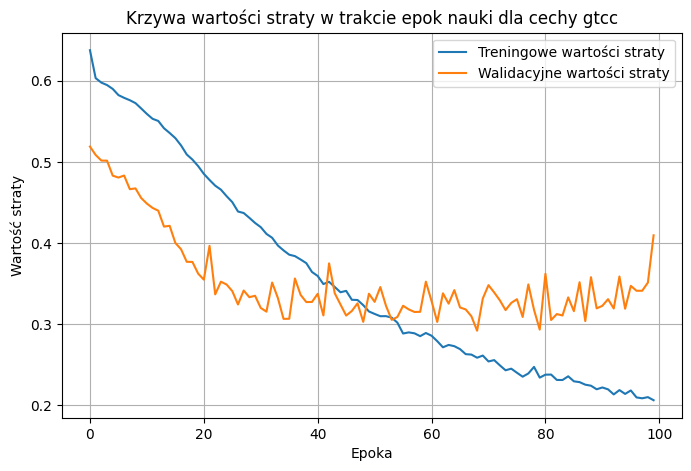

Final Accuracy: 0.8743 | F1 Score: 0.8649 | EER: 0.1249
Final Accuracy: 0.8461 | F1 Score: 0.8259 | EER: 0.1144
Zapisano modele i wyniki dla 'gtcc' → Adam_CrossEntropyLoss_lr0.001_wd0.0001
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.001_wd0.0001\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6403 | Train Acc: 0.6284 | Val Loss: 0.5161 | Val Acc: 0.7758
[mel-spect] Epoch 2/100 | Train Loss: 0.5998 | Train Acc: 0.6659 | Val Loss: 0.4975 | Val Acc: 0.7728
[mel-spect] Epoch 3/100 | Train Loss: 0.5864 | Train Acc: 0.6726 | Val Loss: 0.4717 | Val Acc: 0.7780
[mel-spect] Epoch 4/100 | Train Loss: 0.5750 | Train Acc: 0.6702 | Val Loss: 0.4545 | Val Acc: 0.7765
[mel-spect] Epoch 5/100 | Train Loss: 0.5673 | Train Acc: 0.6744 | Val Loss: 0.4661 | Val Acc: 0.7889
[mel-spect] Epoch 6/100 | Train Loss: 0.5620 | Train Acc: 0.6765 | Val Loss: 0.4467 | Val Acc: 0.7799
[mel-spect] Epoch 7/100 | Train Loss: 0.5512 | Train Acc: 0.

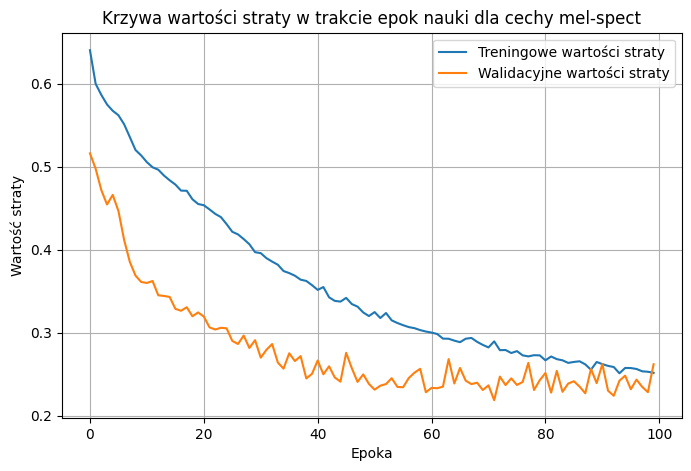

Final Accuracy: 0.9180 | F1 Score: 0.9172 | EER: 0.0873
Final Accuracy: 0.9138 | F1 Score: 0.9124 | EER: 0.0888
Zapisano modele i wyniki dla 'mel-spect' → Adam_CrossEntropyLoss_lr0.001_wd0.0001
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.001_wd0.0001\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6109 | Train Acc: 0.6627 | Val Loss: 0.5034 | Val Acc: 0.7750
[mfcc] Epoch 2/100 | Train Loss: 0.5929 | Train Acc: 0.6744 | Val Loss: 0.4978 | Val Acc: 0.7859
[mfcc] Epoch 3/100 | Train Loss: 0.5752 | Train Acc: 0.6821 | Val Loss: 0.4527 | Val Acc: 0.7818
[mfcc] Epoch 4/100 | Train Loss: 0.5642 | Train Acc: 0.6769 | Val Loss: 0.4438 | Val Acc: 0.7893
[mfcc] Epoch 5/100 | Train Loss: 0.5575 | Train Acc: 0.6823 | Val Loss: 0.4360 | Val Acc: 0.7889
[mfcc] Epoch 6/100 | Train Loss: 0.5434 | Train Acc: 0.6874 | Val Loss: 0.4130 | Val Acc: 0.8017
[mfcc] Epoch 7/100 | Train Loss: 0.5307 | Train Acc: 0.6950 | Val Loss: 0.4039 |

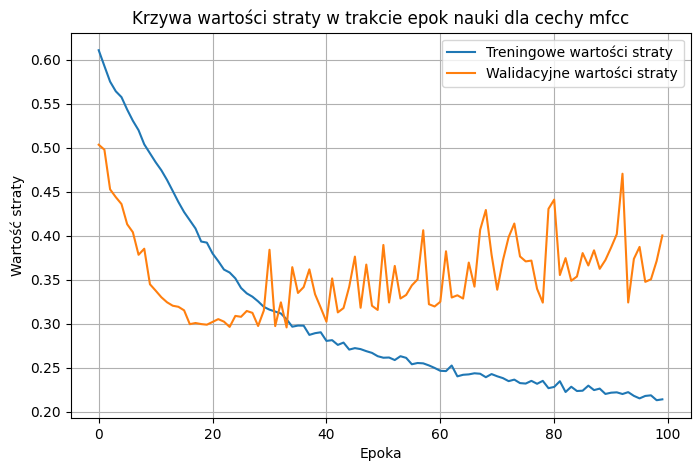

Final Accuracy: 0.8837 | F1 Score: 0.8827 | EER: 0.1121
Final Accuracy: 0.8740 | F1 Score: 0.8655 | EER: 0.1211
Zapisano modele i wyniki dla 'mfcc' → Adam_CrossEntropyLoss_lr0.001_wd0.0001
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.001_wd0.0001\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6221 | Train Acc: 0.6464 | Val Loss: 0.5203 | Val Acc: 0.7731
[lfcc] Epoch 2/100 | Train Loss: 0.5983 | Train Acc: 0.6706 | Val Loss: 0.5009 | Val Acc: 0.7818
[lfcc] Epoch 3/100 | Train Loss: 0.5915 | Train Acc: 0.6717 | Val Loss: 0.5000 | Val Acc: 0.7889
[lfcc] Epoch 4/100 | Train Loss: 0.5892 | Train Acc: 0.6750 | Val Loss: 0.4884 | Val Acc: 0.7852
[lfcc] Epoch 5/100 | Train Loss: 0.5823 | Train Acc: 0.6761 | Val Loss: 0.4871 | Val Acc: 0.7780
[lfcc] Epoch 6/100 | Train Loss: 0.5752 | Train Acc: 0.6844 | Val Loss: 0.4732 | Val Acc: 0.7867
[lfcc] Epoch 7/100 | Train Loss: 0.5681 | Train Acc: 0.6790 | Val Loss: 0.4442 | Val Acc: 0.794

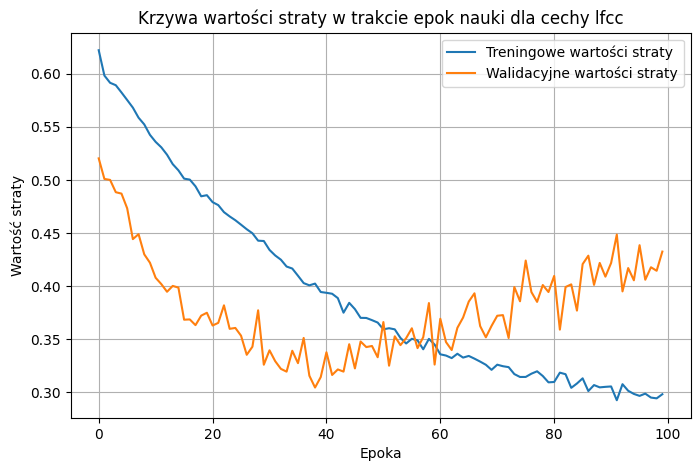

Final Accuracy: 0.8646 | F1 Score: 0.8663 | EER: 0.1369
Final Accuracy: 0.8563 | F1 Score: 0.8538 | EER: 0.1490
Zapisano modele i wyniki dla 'lfcc' → Adam_CrossEntropyLoss_lr0.001_wd0.0001
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.001_wd0.0001\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla Adam_CrossEntropyLoss_lr0.001_wd0.0001 ==========


========== Trening z Adam_CrossEntropyLoss_lr0.0001_wd1e-05 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6897 | Train Acc: 0.5275 | Val Loss: 0.6415 | Val Acc: 0.7630
[cqcc] Epoch 2/100 | Train Loss: 0.6341 | Train Acc: 0.6474 | Val Loss: 0.5368 | Val Acc: 0.7679
[cqcc] Epoch 3/100 | Train Loss: 0.6053 | Train Acc: 0.6747 | Val Loss: 0.5153 | Val Acc: 0.7724
[cqcc] Epoch 4/100 | Train Loss: 0.5950 | Train Acc: 0.6846 | Val Loss: 0.5093 | Val Acc: 0.7769
[cqcc] Epoch 5/100 | Train Loss: 0.5872 | Train Acc: 0.6909 | Val Loss: 0.5007 | Val Acc: 0.7799
[cqcc] Epoch 6/100 | Train Loss: 0.579

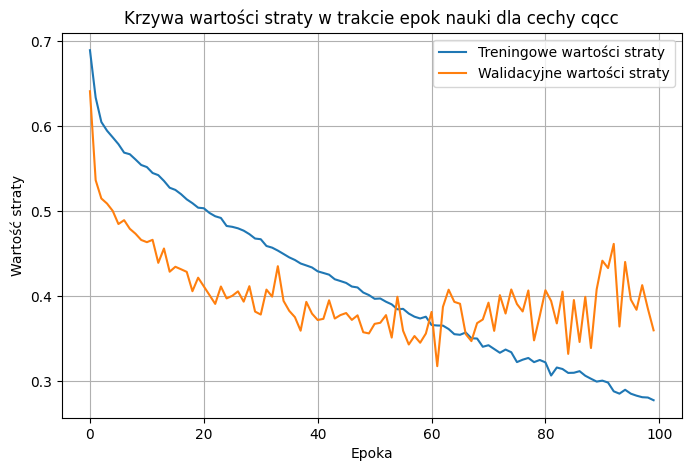

Final Accuracy: 0.8589 | F1 Score: 0.8538 | EER: 0.1302
Final Accuracy: 0.8510 | F1 Score: 0.8354 | EER: 0.1272
Zapisano modele i wyniki dla 'cqcc' → Adam_CrossEntropyLoss_lr0.0001_wd1e-05
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.0001_wd1e-05\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6752 | Train Acc: 0.5834 | Val Loss: 0.5841 | Val Acc: 0.7701
[gtcc] Epoch 2/100 | Train Loss: 0.6258 | Train Acc: 0.6540 | Val Loss: 0.5346 | Val Acc: 0.7750
[gtcc] Epoch 3/100 | Train Loss: 0.6096 | Train Acc: 0.6606 | Val Loss: 0.5205 | Val Acc: 0.7735
[gtcc] Epoch 4/100 | Train Loss: 0.5985 | Train Acc: 0.6711 | Val Loss: 0.5149 | Val Acc: 0.7724
[gtcc] Epoch 5/100 | Train Loss: 0.5944 | Train Acc: 0.6725 | Val Loss: 0.5116 | Val Acc: 0.7709
[gtcc] Epoch 6/100 | Train Loss: 0.5904 | Train Acc: 0.6718 | Val Loss: 0.5087 | Val Acc: 0.7660
[gtcc] Epoch 7/100 | Train Loss: 0.5872 | Train Acc: 0.6735 | Val Loss: 0.4979 | Val Acc: 0.772

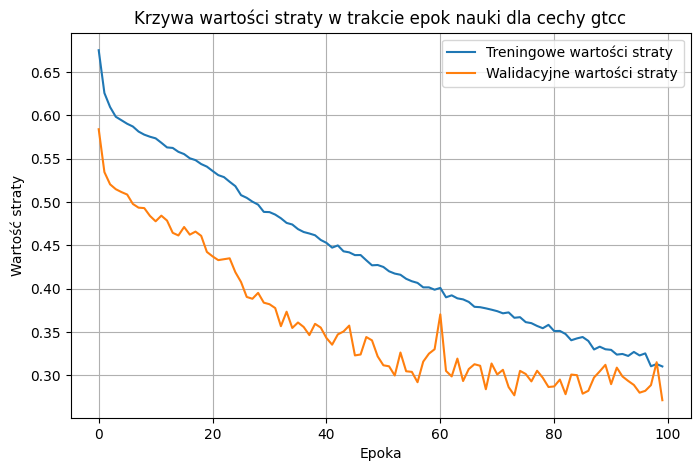

Final Accuracy: 0.8830 | F1 Score: 0.8760 | EER: 0.1114
Final Accuracy: 0.8830 | F1 Score: 0.8760 | EER: 0.1114
Zapisano modele i wyniki dla 'gtcc' → Adam_CrossEntropyLoss_lr0.0001_wd1e-05
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.0001_wd1e-05\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6443 | Train Acc: 0.6165 | Val Loss: 0.5114 | Val Acc: 0.7810
[mel-spect] Epoch 2/100 | Train Loss: 0.5868 | Train Acc: 0.6725 | Val Loss: 0.4756 | Val Acc: 0.7810
[mel-spect] Epoch 3/100 | Train Loss: 0.5749 | Train Acc: 0.6750 | Val Loss: 0.4603 | Val Acc: 0.7848
[mel-spect] Epoch 4/100 | Train Loss: 0.5697 | Train Acc: 0.6764 | Val Loss: 0.4550 | Val Acc: 0.7852
[mel-spect] Epoch 5/100 | Train Loss: 0.5642 | Train Acc: 0.6757 | Val Loss: 0.4610 | Val Acc: 0.7833
[mel-spect] Epoch 6/100 | Train Loss: 0.5632 | Train Acc: 0.6769 | Val Loss: 0.4542 | Val Acc: 0.7807
[mel-spect] Epoch 7/100 | Train Loss: 0.5554 | Train Acc: 0.

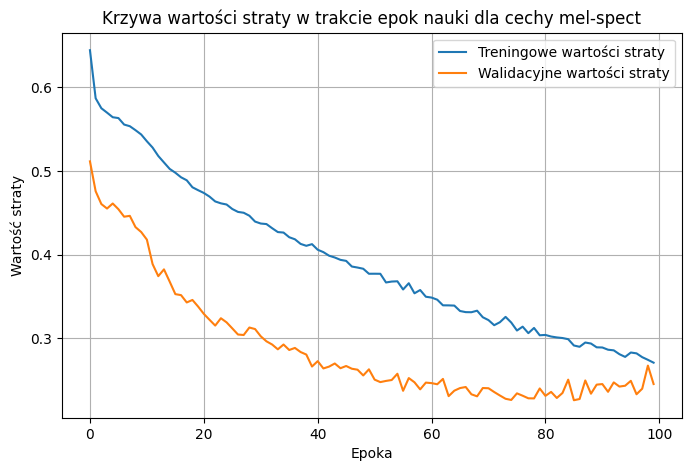

Final Accuracy: 0.9067 | F1 Score: 0.9042 | EER: 0.0910
Final Accuracy: 0.9101 | F1 Score: 0.9067 | EER: 0.0933
Zapisano modele i wyniki dla 'mel-spect' → Adam_CrossEntropyLoss_lr0.0001_wd1e-05
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.0001_wd1e-05\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6528 | Train Acc: 0.6299 | Val Loss: 0.5622 | Val Acc: 0.7600
[mfcc] Epoch 2/100 | Train Loss: 0.6088 | Train Acc: 0.6651 | Val Loss: 0.5213 | Val Acc: 0.7784
[mfcc] Epoch 3/100 | Train Loss: 0.5954 | Train Acc: 0.6705 | Val Loss: 0.5048 | Val Acc: 0.7754
[mfcc] Epoch 4/100 | Train Loss: 0.5857 | Train Acc: 0.6744 | Val Loss: 0.4878 | Val Acc: 0.7825
[mfcc] Epoch 5/100 | Train Loss: 0.5767 | Train Acc: 0.6781 | Val Loss: 0.4805 | Val Acc: 0.7840
[mfcc] Epoch 6/100 | Train Loss: 0.5662 | Train Acc: 0.6804 | Val Loss: 0.4664 | Val Acc: 0.7893
[mfcc] Epoch 7/100 | Train Loss: 0.5592 | Train Acc: 0.6842 | Val Loss: 0.4526 |

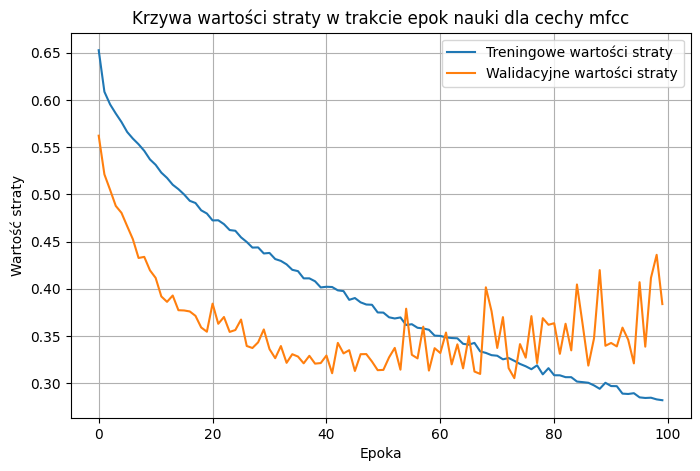

Final Accuracy: 0.8721 | F1 Score: 0.8632 | EER: 0.1219
Final Accuracy: 0.8574 | F1 Score: 0.8408 | EER: 0.1076
Zapisano modele i wyniki dla 'mfcc' → Adam_CrossEntropyLoss_lr0.0001_wd1e-05
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.0001_wd1e-05\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6589 | Train Acc: 0.5928 | Val Loss: 0.5600 | Val Acc: 0.7724
[lfcc] Epoch 2/100 | Train Loss: 0.6101 | Train Acc: 0.6607 | Val Loss: 0.5343 | Val Acc: 0.7758
[lfcc] Epoch 3/100 | Train Loss: 0.5954 | Train Acc: 0.6756 | Val Loss: 0.5171 | Val Acc: 0.7777
[lfcc] Epoch 4/100 | Train Loss: 0.5875 | Train Acc: 0.6786 | Val Loss: 0.5083 | Val Acc: 0.7795
[lfcc] Epoch 5/100 | Train Loss: 0.5834 | Train Acc: 0.6750 | Val Loss: 0.4982 | Val Acc: 0.7859
[lfcc] Epoch 6/100 | Train Loss: 0.5782 | Train Acc: 0.6778 | Val Loss: 0.4983 | Val Acc: 0.7829
[lfcc] Epoch 7/100 | Train Loss: 0.5747 | Train Acc: 0.6802 | Val Loss: 0.4878 | Val Acc: 0.786

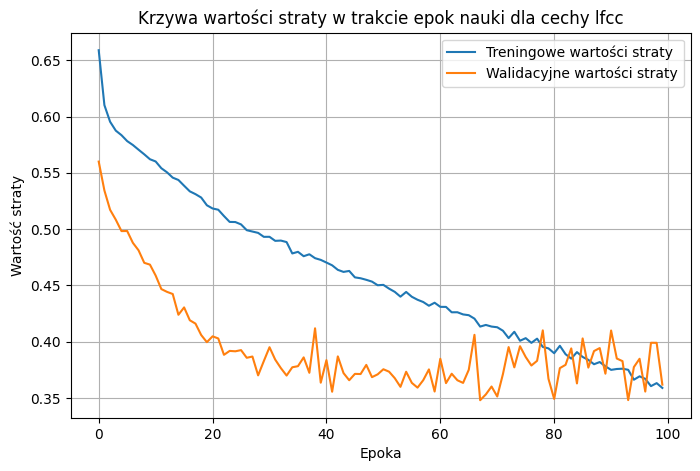

Final Accuracy: 0.8499 | F1 Score: 0.8422 | EER: 0.1437
Final Accuracy: 0.8450 | F1 Score: 0.8331 | EER: 0.1452
Zapisano modele i wyniki dla 'lfcc' → Adam_CrossEntropyLoss_lr0.0001_wd1e-05
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.0001_wd1e-05\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla Adam_CrossEntropyLoss_lr0.0001_wd1e-05 ==========


========== Trening z Adam_CrossEntropyLoss_lr0.0001_wd0.0001 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6716 | Train Acc: 0.5769 | Val Loss: 0.5775 | Val Acc: 0.7686
[cqcc] Epoch 2/100 | Train Loss: 0.6166 | Train Acc: 0.6619 | Val Loss: 0.5216 | Val Acc: 0.7731
[cqcc] Epoch 3/100 | Train Loss: 0.5998 | Train Acc: 0.6782 | Val Loss: 0.5101 | Val Acc: 0.7765
[cqcc] Epoch 4/100 | Train Loss: 0.5899 | Train Acc: 0.6875 | Val Loss: 0.4969 | Val Acc: 0.7803
[cqcc] Epoch 5/100 | Train Loss: 0.5812 | Train Acc: 0.6925 | Val Loss: 0.5007 | Val Acc: 0.7814
[cqcc] Epoch 6/100 | Train Loss: 0.57

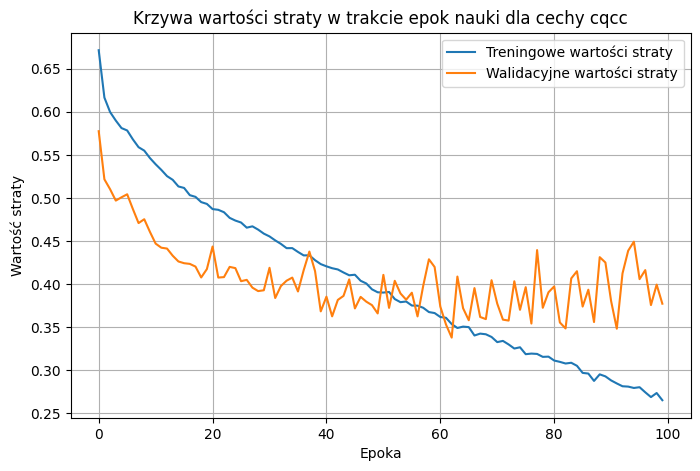

Final Accuracy: 0.8559 | F1 Score: 0.8428 | EER: 0.1324
Final Accuracy: 0.8518 | F1 Score: 0.8354 | EER: 0.1219
Zapisano modele i wyniki dla 'cqcc' → Adam_CrossEntropyLoss_lr0.0001_wd0.0001
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.0001_wd0.0001\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6811 | Train Acc: 0.5690 | Val Loss: 0.5840 | Val Acc: 0.7682
[gtcc] Epoch 2/100 | Train Loss: 0.6278 | Train Acc: 0.6542 | Val Loss: 0.5295 | Val Acc: 0.7743
[gtcc] Epoch 3/100 | Train Loss: 0.6093 | Train Acc: 0.6680 | Val Loss: 0.5256 | Val Acc: 0.7709
[gtcc] Epoch 4/100 | Train Loss: 0.6008 | Train Acc: 0.6731 | Val Loss: 0.5106 | Val Acc: 0.7773
[gtcc] Epoch 5/100 | Train Loss: 0.5955 | Train Acc: 0.6707 | Val Loss: 0.5091 | Val Acc: 0.7705
[gtcc] Epoch 6/100 | Train Loss: 0.5913 | Train Acc: 0.6759 | Val Loss: 0.5015 | Val Acc: 0.7701
[gtcc] Epoch 7/100 | Train Loss: 0.5862 | Train Acc: 0.6748 | Val Loss: 0.4973 | Val Acc: 0.7

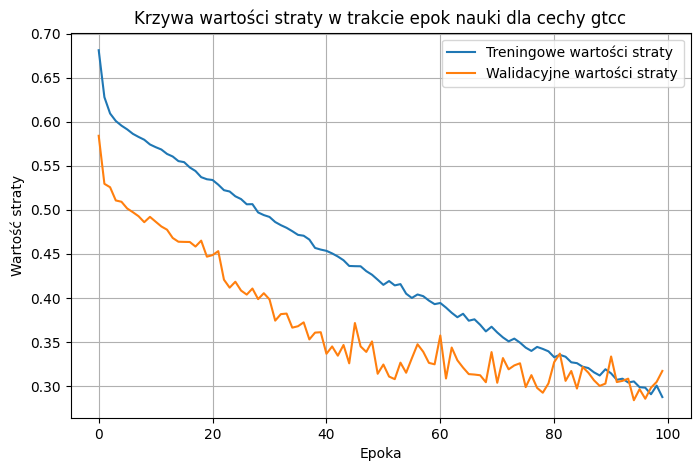

Final Accuracy: 0.8834 | F1 Score: 0.8785 | EER: 0.1159
Final Accuracy: 0.8698 | F1 Score: 0.8592 | EER: 0.1181
Zapisano modele i wyniki dla 'gtcc' → Adam_CrossEntropyLoss_lr0.0001_wd0.0001
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.0001_wd0.0001\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6624 | Train Acc: 0.5907 | Val Loss: 0.5766 | Val Acc: 0.7581
[mel-spect] Epoch 2/100 | Train Loss: 0.6117 | Train Acc: 0.6588 | Val Loss: 0.5225 | Val Acc: 0.7765
[mel-spect] Epoch 3/100 | Train Loss: 0.5893 | Train Acc: 0.6678 | Val Loss: 0.4890 | Val Acc: 0.7799
[mel-spect] Epoch 4/100 | Train Loss: 0.5755 | Train Acc: 0.6726 | Val Loss: 0.4766 | Val Acc: 0.7814
[mel-spect] Epoch 5/100 | Train Loss: 0.5680 | Train Acc: 0.6775 | Val Loss: 0.4681 | Val Acc: 0.7807
[mel-spect] Epoch 6/100 | Train Loss: 0.5643 | Train Acc: 0.6789 | Val Loss: 0.4574 | Val Acc: 0.7874
[mel-spect] Epoch 7/100 | Train Loss: 0.5581 | Train Acc: 

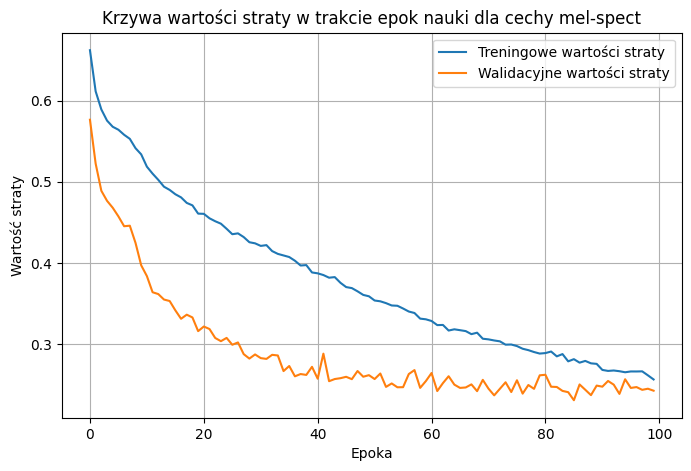

Final Accuracy: 0.9093 | F1 Score: 0.9071 | EER: 0.0910
Final Accuracy: 0.9074 | F1 Score: 0.9044 | EER: 0.0910
Zapisano modele i wyniki dla 'mel-spect' → Adam_CrossEntropyLoss_lr0.0001_wd0.0001
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.0001_wd0.0001\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6448 | Train Acc: 0.6276 | Val Loss: 0.5443 | Val Acc: 0.7682
[mfcc] Epoch 2/100 | Train Loss: 0.6019 | Train Acc: 0.6728 | Val Loss: 0.5082 | Val Acc: 0.7814
[mfcc] Epoch 3/100 | Train Loss: 0.5866 | Train Acc: 0.6786 | Val Loss: 0.4865 | Val Acc: 0.7878
[mfcc] Epoch 4/100 | Train Loss: 0.5783 | Train Acc: 0.6775 | Val Loss: 0.4685 | Val Acc: 0.7953
[mfcc] Epoch 5/100 | Train Loss: 0.5673 | Train Acc: 0.6864 | Val Loss: 0.4519 | Val Acc: 0.8040
[mfcc] Epoch 6/100 | Train Loss: 0.5571 | Train Acc: 0.6883 | Val Loss: 0.4336 | Val Acc: 0.8081
[mfcc] Epoch 7/100 | Train Loss: 0.5513 | Train Acc: 0.6955 | Val Loss: 0.4270

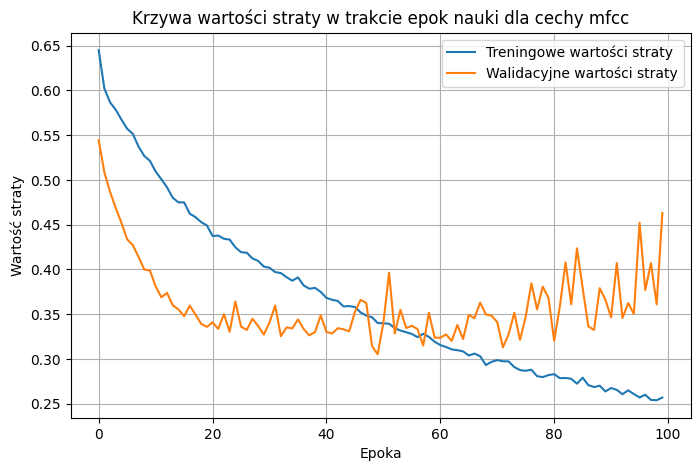

Final Accuracy: 0.8762 | F1 Score: 0.8700 | EER: 0.1302
Final Accuracy: 0.8506 | F1 Score: 0.8301 | EER: 0.1196
Zapisano modele i wyniki dla 'mfcc' → Adam_CrossEntropyLoss_lr0.0001_wd0.0001
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.0001_wd0.0001\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6705 | Train Acc: 0.5661 | Val Loss: 0.5949 | Val Acc: 0.7457
[lfcc] Epoch 2/100 | Train Loss: 0.6160 | Train Acc: 0.6549 | Val Loss: 0.5389 | Val Acc: 0.7724
[lfcc] Epoch 3/100 | Train Loss: 0.5986 | Train Acc: 0.6673 | Val Loss: 0.5303 | Val Acc: 0.7724
[lfcc] Epoch 4/100 | Train Loss: 0.5879 | Train Acc: 0.6735 | Val Loss: 0.5119 | Val Acc: 0.7746
[lfcc] Epoch 5/100 | Train Loss: 0.5846 | Train Acc: 0.6759 | Val Loss: 0.5082 | Val Acc: 0.7784
[lfcc] Epoch 6/100 | Train Loss: 0.5813 | Train Acc: 0.6758 | Val Loss: 0.5044 | Val Acc: 0.7799
[lfcc] Epoch 7/100 | Train Loss: 0.5784 | Train Acc: 0.6777 | Val Loss: 0.5041 | Val Acc: 0.7

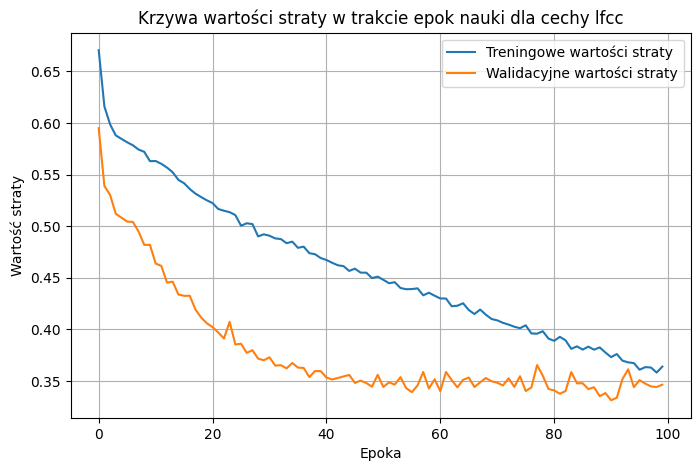

Final Accuracy: 0.8585 | F1 Score: 0.8557 | EER: 0.1400
Final Accuracy: 0.8638 | F1 Score: 0.8594 | EER: 0.1332
Zapisano modele i wyniki dla 'lfcc' → Adam_CrossEntropyLoss_lr0.0001_wd0.0001
Folder: Res_Net\Adam_CrossEntropyLoss_lr0.0001_wd0.0001\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla Adam_CrossEntropyLoss_lr0.0001_wd0.0001 ==========


========== Trening z AdamW_CrossEntropyLoss_lr0.001_wd1e-05 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6395 | Train Acc: 0.6373 | Val Loss: 0.5257 | Val Acc: 0.7765
[cqcc] Epoch 2/100 | Train Loss: 0.6040 | Train Acc: 0.6777 | Val Loss: 0.5113 | Val Acc: 0.7750
[cqcc] Epoch 3/100 | Train Loss: 0.6016 | Train Acc: 0.6831 | Val Loss: 0.5090 | Val Acc: 0.7758
[cqcc] Epoch 4/100 | Train Loss: 0.5948 | Train Acc: 0.6916 | Val Loss: 0.5032 | Val Acc: 0.7784
[cqcc] Epoch 5/100 | Train Loss: 0.5875 | Train Acc: 0.6971 | Val Loss: 0.5003 | Val Acc: 0.7780
[cqcc] Epoch 6/100 | Train Loss: 0.

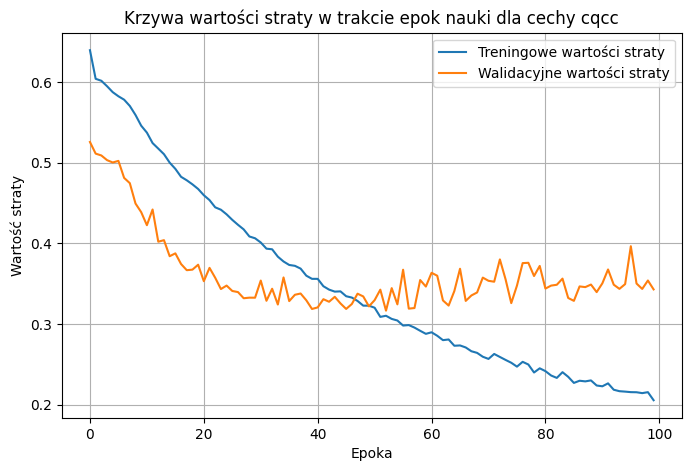

Final Accuracy: 0.8661 | F1 Score: 0.8663 | EER: 0.1332
Final Accuracy: 0.8837 | F1 Score: 0.8833 | EER: 0.1166
Zapisano modele i wyniki dla 'cqcc' → AdamW_CrossEntropyLoss_lr0.001_wd1e-05
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.001_wd1e-05\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6417 | Train Acc: 0.6176 | Val Loss: 0.5124 | Val Acc: 0.7777
[gtcc] Epoch 2/100 | Train Loss: 0.6044 | Train Acc: 0.6619 | Val Loss: 0.5047 | Val Acc: 0.7754
[gtcc] Epoch 3/100 | Train Loss: 0.5981 | Train Acc: 0.6676 | Val Loss: 0.5001 | Val Acc: 0.7777
[gtcc] Epoch 4/100 | Train Loss: 0.5902 | Train Acc: 0.6738 | Val Loss: 0.4822 | Val Acc: 0.7788
[gtcc] Epoch 5/100 | Train Loss: 0.5854 | Train Acc: 0.6779 | Val Loss: 0.4792 | Val Acc: 0.7818
[gtcc] Epoch 6/100 | Train Loss: 0.5774 | Train Acc: 0.6838 | Val Loss: 0.4737 | Val Acc: 0.7889
[gtcc] Epoch 7/100 | Train Loss: 0.5743 | Train Acc: 0.6898 | Val Loss: 0.4663 | Val Acc: 0.787

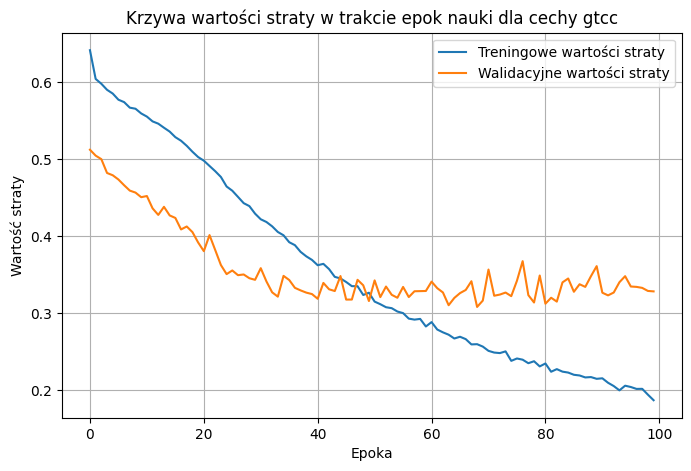

Final Accuracy: 0.8796 | F1 Score: 0.8749 | EER: 0.1211
Final Accuracy: 0.8868 | F1 Score: 0.8860 | EER: 0.1136
Zapisano modele i wyniki dla 'gtcc' → AdamW_CrossEntropyLoss_lr0.001_wd1e-05
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.001_wd1e-05\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6333 | Train Acc: 0.6284 | Val Loss: 0.4867 | Val Acc: 0.7739
[mel-spect] Epoch 2/100 | Train Loss: 0.5879 | Train Acc: 0.6678 | Val Loss: 0.4655 | Val Acc: 0.7784
[mel-spect] Epoch 3/100 | Train Loss: 0.5719 | Train Acc: 0.6746 | Val Loss: 0.4606 | Val Acc: 0.7731
[mel-spect] Epoch 4/100 | Train Loss: 0.5691 | Train Acc: 0.6734 | Val Loss: 0.4566 | Val Acc: 0.7746
[mel-spect] Epoch 5/100 | Train Loss: 0.5596 | Train Acc: 0.6779 | Val Loss: 0.4476 | Val Acc: 0.7765
[mel-spect] Epoch 6/100 | Train Loss: 0.5497 | Train Acc: 0.6813 | Val Loss: 0.3961 | Val Acc: 0.8277
[mel-spect] Epoch 7/100 | Train Loss: 0.5327 | Train Acc: 0.

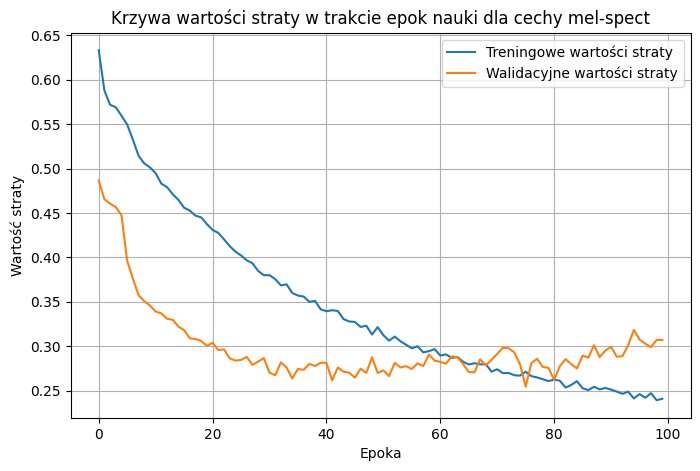

Final Accuracy: 0.9048 | F1 Score: 0.9049 | EER: 0.0956
Final Accuracy: 0.9071 | F1 Score: 0.9049 | EER: 0.0910
Zapisano modele i wyniki dla 'mel-spect' → AdamW_CrossEntropyLoss_lr0.001_wd1e-05
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.001_wd1e-05\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6174 | Train Acc: 0.6540 | Val Loss: 0.5277 | Val Acc: 0.7754
[mfcc] Epoch 2/100 | Train Loss: 0.5954 | Train Acc: 0.6735 | Val Loss: 0.5088 | Val Acc: 0.7799
[mfcc] Epoch 3/100 | Train Loss: 0.5890 | Train Acc: 0.6750 | Val Loss: 0.4930 | Val Acc: 0.7777
[mfcc] Epoch 4/100 | Train Loss: 0.5801 | Train Acc: 0.6777 | Val Loss: 0.4524 | Val Acc: 0.7844
[mfcc] Epoch 5/100 | Train Loss: 0.5647 | Train Acc: 0.6843 | Val Loss: 0.4440 | Val Acc: 0.7912
[mfcc] Epoch 6/100 | Train Loss: 0.5496 | Train Acc: 0.6885 | Val Loss: 0.4031 | Val Acc: 0.8160
[mfcc] Epoch 7/100 | Train Loss: 0.5369 | Train Acc: 0.6965 | Val Loss: 0.3910 |

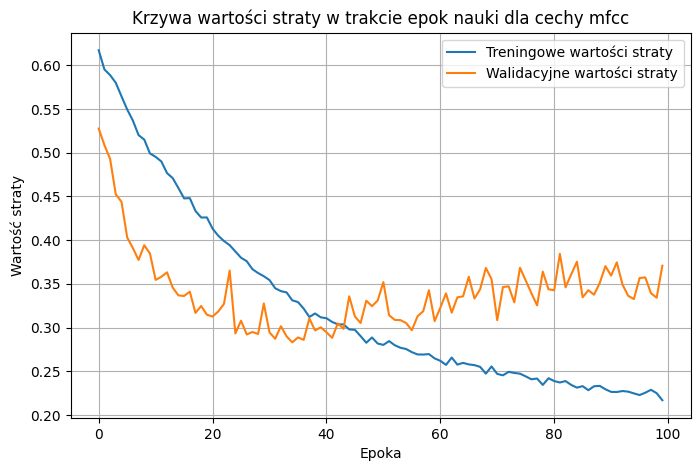

Final Accuracy: 0.8785 | F1 Score: 0.8758 | EER: 0.1204
Final Accuracy: 0.8871 | F1 Score: 0.8849 | EER: 0.1114
Zapisano modele i wyniki dla 'mfcc' → AdamW_CrossEntropyLoss_lr0.001_wd1e-05
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.001_wd1e-05\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6275 | Train Acc: 0.6438 | Val Loss: 0.5291 | Val Acc: 0.7773
[lfcc] Epoch 2/100 | Train Loss: 0.6000 | Train Acc: 0.6661 | Val Loss: 0.5126 | Val Acc: 0.7795
[lfcc] Epoch 3/100 | Train Loss: 0.5952 | Train Acc: 0.6689 | Val Loss: 0.5103 | Val Acc: 0.7814
[lfcc] Epoch 4/100 | Train Loss: 0.5899 | Train Acc: 0.6746 | Val Loss: 0.4889 | Val Acc: 0.7799
[lfcc] Epoch 5/100 | Train Loss: 0.5856 | Train Acc: 0.6732 | Val Loss: 0.4941 | Val Acc: 0.7886
[lfcc] Epoch 6/100 | Train Loss: 0.5804 | Train Acc: 0.6778 | Val Loss: 0.4766 | Val Acc: 0.7856
[lfcc] Epoch 7/100 | Train Loss: 0.5737 | Train Acc: 0.6826 | Val Loss: 0.4660 | Val Acc: 0.791

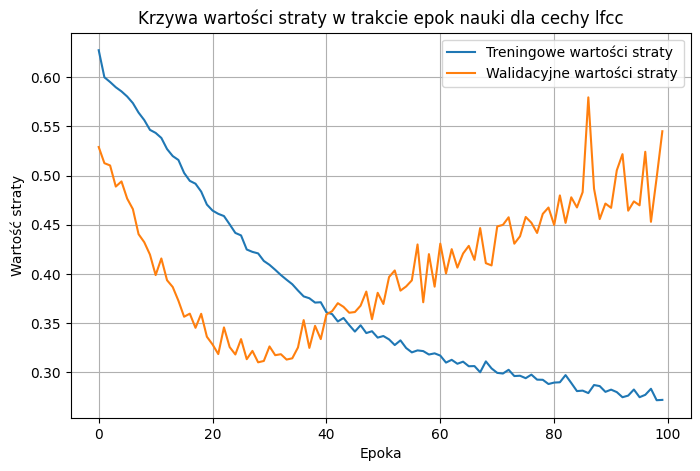

Final Accuracy: 0.8713 | F1 Score: 0.8681 | EER: 0.1339
Final Accuracy: 0.8567 | F1 Score: 0.8599 | EER: 0.1400
Zapisano modele i wyniki dla 'lfcc' → AdamW_CrossEntropyLoss_lr0.001_wd1e-05
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.001_wd1e-05\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla AdamW_CrossEntropyLoss_lr0.001_wd1e-05 ==========


========== Trening z AdamW_CrossEntropyLoss_lr0.001_wd0.0001 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6501 | Train Acc: 0.6105 | Val Loss: 0.5248 | Val Acc: 0.7724
[cqcc] Epoch 2/100 | Train Loss: 0.6038 | Train Acc: 0.6784 | Val Loss: 0.5281 | Val Acc: 0.7679
[cqcc] Epoch 3/100 | Train Loss: 0.5933 | Train Acc: 0.6976 | Val Loss: 0.5370 | Val Acc: 0.7622
[cqcc] Epoch 4/100 | Train Loss: 0.5898 | Train Acc: 0.6986 | Val Loss: 0.5187 | Val Acc: 0.7709
[cqcc] Epoch 5/100 | Train Loss: 0.5849 | Train Acc: 0.7058 | Val Loss: 0.5097 | Val Acc: 0.7709
[cqcc] Epoch 6/100 | Train Loss: 0.57

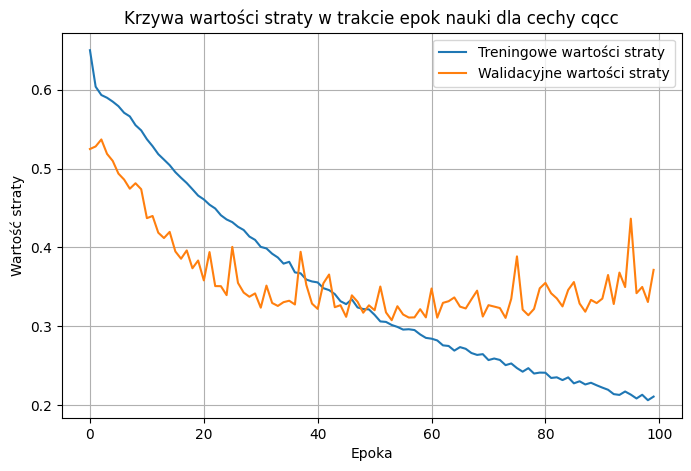

Final Accuracy: 0.8695 | F1 Score: 0.8707 | EER: 0.1272
Final Accuracy: 0.8612 | F1 Score: 0.8552 | EER: 0.1287
Zapisano modele i wyniki dla 'cqcc' → AdamW_CrossEntropyLoss_lr0.001_wd0.0001
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.001_wd0.0001\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6400 | Train Acc: 0.6231 | Val Loss: 0.5133 | Val Acc: 0.7731
[gtcc] Epoch 2/100 | Train Loss: 0.6026 | Train Acc: 0.6639 | Val Loss: 0.4999 | Val Acc: 0.7810
[gtcc] Epoch 3/100 | Train Loss: 0.5937 | Train Acc: 0.6726 | Val Loss: 0.4887 | Val Acc: 0.7803
[gtcc] Epoch 4/100 | Train Loss: 0.5871 | Train Acc: 0.6781 | Val Loss: 0.4935 | Val Acc: 0.7818
[gtcc] Epoch 5/100 | Train Loss: 0.5811 | Train Acc: 0.6826 | Val Loss: 0.4830 | Val Acc: 0.7814
[gtcc] Epoch 6/100 | Train Loss: 0.5767 | Train Acc: 0.6862 | Val Loss: 0.4839 | Val Acc: 0.7852
[gtcc] Epoch 7/100 | Train Loss: 0.5706 | Train Acc: 0.6876 | Val Loss: 0.4617 | Val Acc: 0.7

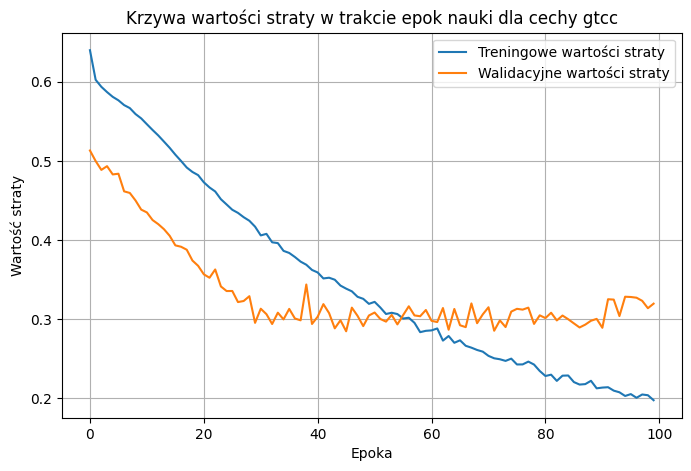

Final Accuracy: 0.8781 | F1 Score: 0.8733 | EER: 0.1219
Final Accuracy: 0.8807 | F1 Score: 0.8807 | EER: 0.1189
Zapisano modele i wyniki dla 'gtcc' → AdamW_CrossEntropyLoss_lr0.001_wd0.0001
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.001_wd0.0001\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6379 | Train Acc: 0.6278 | Val Loss: 0.5189 | Val Acc: 0.7788
[mel-spect] Epoch 2/100 | Train Loss: 0.5980 | Train Acc: 0.6726 | Val Loss: 0.4787 | Val Acc: 0.7833
[mel-spect] Epoch 3/100 | Train Loss: 0.5820 | Train Acc: 0.6721 | Val Loss: 0.4723 | Val Acc: 0.7769
[mel-spect] Epoch 4/100 | Train Loss: 0.5719 | Train Acc: 0.6726 | Val Loss: 0.4588 | Val Acc: 0.7859
[mel-spect] Epoch 5/100 | Train Loss: 0.5665 | Train Acc: 0.6762 | Val Loss: 0.4509 | Val Acc: 0.7799
[mel-spect] Epoch 6/100 | Train Loss: 0.5587 | Train Acc: 0.6774 | Val Loss: 0.4284 | Val Acc: 0.7980
[mel-spect] Epoch 7/100 | Train Loss: 0.5494 | Train Acc: 

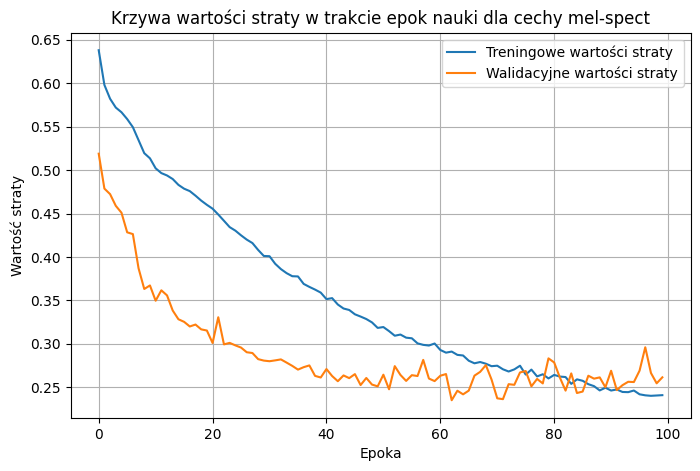

Final Accuracy: 0.9123 | F1 Score: 0.9118 | EER: 0.0858
Final Accuracy: 0.9161 | F1 Score: 0.9143 | EER: 0.0783
Zapisano modele i wyniki dla 'mel-spect' → AdamW_CrossEntropyLoss_lr0.001_wd0.0001
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.001_wd0.0001\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6145 | Train Acc: 0.6548 | Val Loss: 0.5065 | Val Acc: 0.7773
[mfcc] Epoch 2/100 | Train Loss: 0.5960 | Train Acc: 0.6737 | Val Loss: 0.5233 | Val Acc: 0.7788
[mfcc] Epoch 3/100 | Train Loss: 0.5901 | Train Acc: 0.6733 | Val Loss: 0.4934 | Val Acc: 0.7784
[mfcc] Epoch 4/100 | Train Loss: 0.5781 | Train Acc: 0.6754 | Val Loss: 0.4640 | Val Acc: 0.7822
[mfcc] Epoch 5/100 | Train Loss: 0.5638 | Train Acc: 0.6793 | Val Loss: 0.4325 | Val Acc: 0.7946
[mfcc] Epoch 6/100 | Train Loss: 0.5461 | Train Acc: 0.6912 | Val Loss: 0.4278 | Val Acc: 0.7995
[mfcc] Epoch 7/100 | Train Loss: 0.5300 | Train Acc: 0.6954 | Val Loss: 0.3952

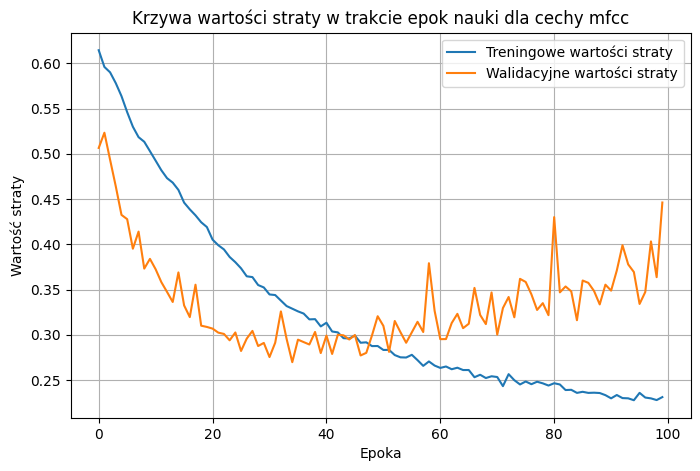

Final Accuracy: 0.8822 | F1 Score: 0.8801 | EER: 0.1196
Final Accuracy: 0.8841 | F1 Score: 0.8768 | EER: 0.1099
Zapisano modele i wyniki dla 'mfcc' → AdamW_CrossEntropyLoss_lr0.001_wd0.0001
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.001_wd0.0001\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6276 | Train Acc: 0.6409 | Val Loss: 0.5112 | Val Acc: 0.7840
[lfcc] Epoch 2/100 | Train Loss: 0.6002 | Train Acc: 0.6680 | Val Loss: 0.5112 | Val Acc: 0.7788
[lfcc] Epoch 3/100 | Train Loss: 0.5941 | Train Acc: 0.6694 | Val Loss: 0.5014 | Val Acc: 0.7777
[lfcc] Epoch 4/100 | Train Loss: 0.5877 | Train Acc: 0.6773 | Val Loss: 0.4907 | Val Acc: 0.7833
[lfcc] Epoch 5/100 | Train Loss: 0.5838 | Train Acc: 0.6759 | Val Loss: 0.4749 | Val Acc: 0.7908
[lfcc] Epoch 6/100 | Train Loss: 0.5772 | Train Acc: 0.6764 | Val Loss: 0.4734 | Val Acc: 0.7908
[lfcc] Epoch 7/100 | Train Loss: 0.5702 | Train Acc: 0.6755 | Val Loss: 0.4597 | Val Acc: 0.7

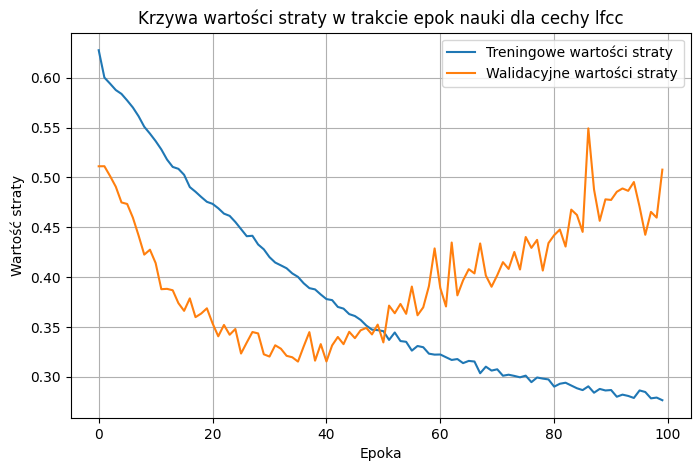

Final Accuracy: 0.8728 | F1 Score: 0.8722 | EER: 0.1287
Final Accuracy: 0.8533 | F1 Score: 0.8559 | EER: 0.1430
Zapisano modele i wyniki dla 'lfcc' → AdamW_CrossEntropyLoss_lr0.001_wd0.0001
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.001_wd0.0001\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla AdamW_CrossEntropyLoss_lr0.001_wd0.0001 ==========


========== Trening z AdamW_CrossEntropyLoss_lr0.0001_wd1e-05 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6786 | Train Acc: 0.5640 | Val Loss: 0.6098 | Val Acc: 0.7660
[cqcc] Epoch 2/100 | Train Loss: 0.6262 | Train Acc: 0.6608 | Val Loss: 0.5395 | Val Acc: 0.7777
[cqcc] Epoch 3/100 | Train Loss: 0.6064 | Train Acc: 0.6742 | Val Loss: 0.5245 | Val Acc: 0.7792
[cqcc] Epoch 4/100 | Train Loss: 0.5951 | Train Acc: 0.6877 | Val Loss: 0.5201 | Val Acc: 0.7731
[cqcc] Epoch 5/100 | Train Loss: 0.5863 | Train Acc: 0.6951 | Val Loss: 0.5224 | Val Acc: 0.7784
[cqcc] Epoch 6/100 | Train Loss: 0

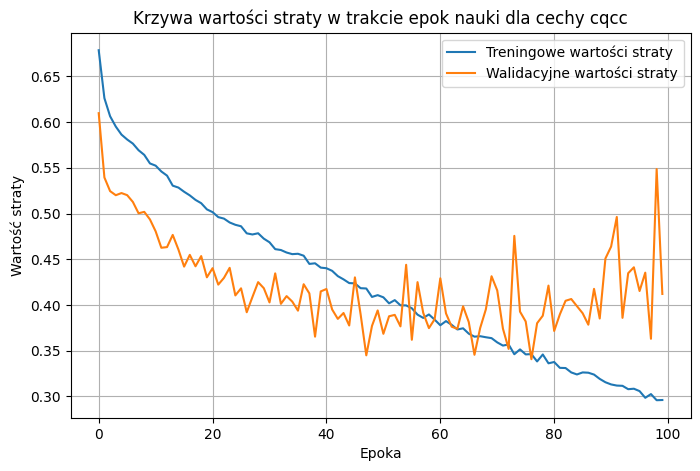

Final Accuracy: 0.8600 | F1 Score: 0.8449 | EER: 0.1317
Final Accuracy: 0.8273 | F1 Score: 0.7957 | EER: 0.1196
Zapisano modele i wyniki dla 'cqcc' → AdamW_CrossEntropyLoss_lr0.0001_wd1e-05
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.0001_wd1e-05\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6863 | Train Acc: 0.5560 | Val Loss: 0.6089 | Val Acc: 0.7641
[gtcc] Epoch 2/100 | Train Loss: 0.6377 | Train Acc: 0.6433 | Val Loss: 0.5418 | Val Acc: 0.7758
[gtcc] Epoch 3/100 | Train Loss: 0.6113 | Train Acc: 0.6685 | Val Loss: 0.5208 | Val Acc: 0.7758
[gtcc] Epoch 4/100 | Train Loss: 0.6005 | Train Acc: 0.6707 | Val Loss: 0.5103 | Val Acc: 0.7731
[gtcc] Epoch 5/100 | Train Loss: 0.5942 | Train Acc: 0.6756 | Val Loss: 0.5041 | Val Acc: 0.7750
[gtcc] Epoch 6/100 | Train Loss: 0.5927 | Train Acc: 0.6721 | Val Loss: 0.5051 | Val Acc: 0.7698
[gtcc] Epoch 7/100 | Train Loss: 0.5891 | Train Acc: 0.6721 | Val Loss: 0.5068 | Val Acc: 0.7

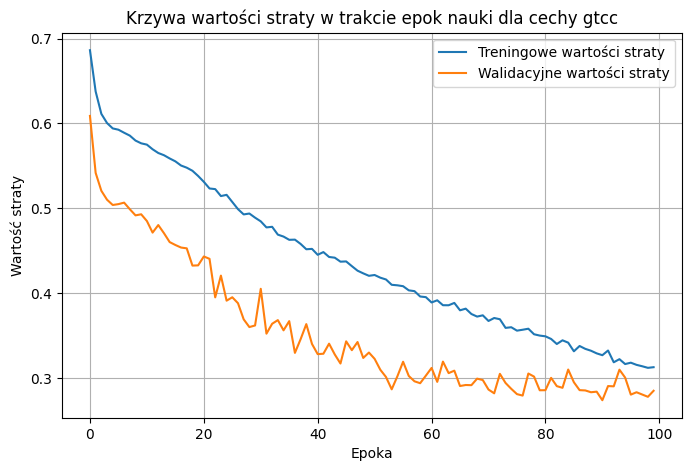

Final Accuracy: 0.8834 | F1 Score: 0.8777 | EER: 0.1046
Final Accuracy: 0.8751 | F1 Score: 0.8654 | EER: 0.1031
Zapisano modele i wyniki dla 'gtcc' → AdamW_CrossEntropyLoss_lr0.0001_wd1e-05
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.0001_wd1e-05\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6496 | Train Acc: 0.6064 | Val Loss: 0.5243 | Val Acc: 0.7720
[mel-spect] Epoch 2/100 | Train Loss: 0.5922 | Train Acc: 0.6640 | Val Loss: 0.4846 | Val Acc: 0.7799
[mel-spect] Epoch 3/100 | Train Loss: 0.5787 | Train Acc: 0.6721 | Val Loss: 0.4706 | Val Acc: 0.7814
[mel-spect] Epoch 4/100 | Train Loss: 0.5698 | Train Acc: 0.6767 | Val Loss: 0.4622 | Val Acc: 0.7863
[mel-spect] Epoch 5/100 | Train Loss: 0.5659 | Train Acc: 0.6763 | Val Loss: 0.4537 | Val Acc: 0.7912
[mel-spect] Epoch 6/100 | Train Loss: 0.5582 | Train Acc: 0.6837 | Val Loss: 0.4587 | Val Acc: 0.7859
[mel-spect] Epoch 7/100 | Train Loss: 0.5580 | Train Acc: 

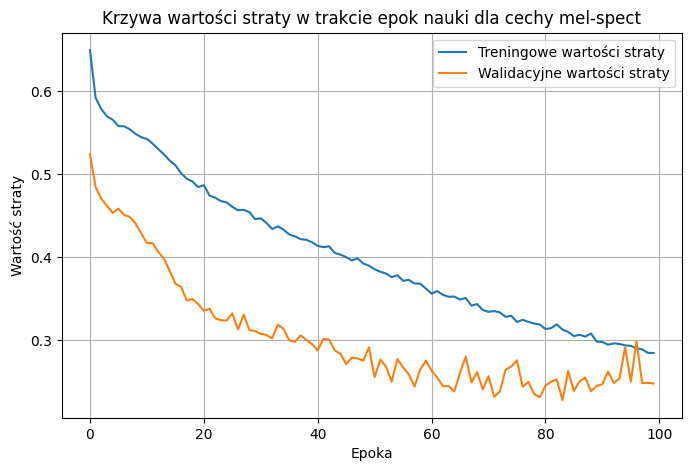

Final Accuracy: 0.9056 | F1 Score: 0.9028 | EER: 0.0880
Final Accuracy: 0.9071 | F1 Score: 0.9038 | EER: 0.0895
Zapisano modele i wyniki dla 'mel-spect' → AdamW_CrossEntropyLoss_lr0.0001_wd1e-05
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.0001_wd1e-05\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6436 | Train Acc: 0.6366 | Val Loss: 0.5411 | Val Acc: 0.7761
[mfcc] Epoch 2/100 | Train Loss: 0.6071 | Train Acc: 0.6680 | Val Loss: 0.5089 | Val Acc: 0.7803
[mfcc] Epoch 3/100 | Train Loss: 0.5916 | Train Acc: 0.6787 | Val Loss: 0.5010 | Val Acc: 0.7818
[mfcc] Epoch 4/100 | Train Loss: 0.5806 | Train Acc: 0.6842 | Val Loss: 0.4767 | Val Acc: 0.7852
[mfcc] Epoch 5/100 | Train Loss: 0.5693 | Train Acc: 0.6804 | Val Loss: 0.4653 | Val Acc: 0.7859
[mfcc] Epoch 6/100 | Train Loss: 0.5608 | Train Acc: 0.6851 | Val Loss: 0.4455 | Val Acc: 0.7889
[mfcc] Epoch 7/100 | Train Loss: 0.5525 | Train Acc: 0.6840 | Val Loss: 0.4461

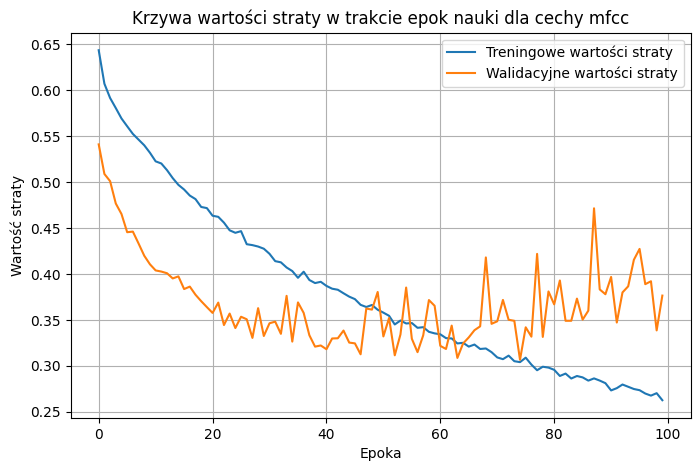

Final Accuracy: 0.8815 | F1 Score: 0.8722 | EER: 0.1174
Final Accuracy: 0.8713 | F1 Score: 0.8579 | EER: 0.1106
Zapisano modele i wyniki dla 'mfcc' → AdamW_CrossEntropyLoss_lr0.0001_wd1e-05
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.0001_wd1e-05\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6535 | Train Acc: 0.5997 | Val Loss: 0.5721 | Val Acc: 0.7671
[lfcc] Epoch 2/100 | Train Loss: 0.6153 | Train Acc: 0.6557 | Val Loss: 0.5378 | Val Acc: 0.7780
[lfcc] Epoch 3/100 | Train Loss: 0.5989 | Train Acc: 0.6668 | Val Loss: 0.5252 | Val Acc: 0.7777
[lfcc] Epoch 4/100 | Train Loss: 0.5917 | Train Acc: 0.6727 | Val Loss: 0.5050 | Val Acc: 0.7814
[lfcc] Epoch 5/100 | Train Loss: 0.5855 | Train Acc: 0.6777 | Val Loss: 0.5151 | Val Acc: 0.7761
[lfcc] Epoch 6/100 | Train Loss: 0.5829 | Train Acc: 0.6744 | Val Loss: 0.5063 | Val Acc: 0.7750
[lfcc] Epoch 7/100 | Train Loss: 0.5798 | Train Acc: 0.6807 | Val Loss: 0.4913 | Val Acc: 0.7

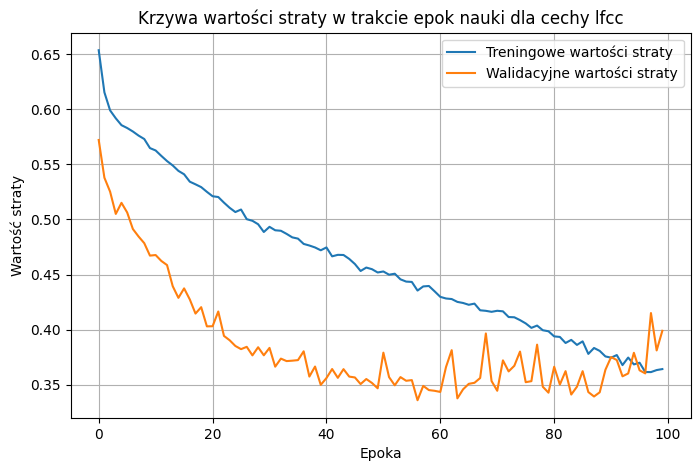

Final Accuracy: 0.8555 | F1 Score: 0.8534 | EER: 0.1422
Final Accuracy: 0.8311 | F1 Score: 0.8097 | EER: 0.1384
Zapisano modele i wyniki dla 'lfcc' → AdamW_CrossEntropyLoss_lr0.0001_wd1e-05
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.0001_wd1e-05\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla AdamW_CrossEntropyLoss_lr0.0001_wd1e-05 ==========


========== Trening z AdamW_CrossEntropyLoss_lr0.0001_wd0.0001 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6763 | Train Acc: 0.5620 | Val Loss: 0.5745 | Val Acc: 0.7682
[cqcc] Epoch 2/100 | Train Loss: 0.6215 | Train Acc: 0.6597 | Val Loss: 0.5239 | Val Acc: 0.7765
[cqcc] Epoch 3/100 | Train Loss: 0.6040 | Train Acc: 0.6773 | Val Loss: 0.5088 | Val Acc: 0.7761
[cqcc] Epoch 4/100 | Train Loss: 0.5928 | Train Acc: 0.6876 | Val Loss: 0.5035 | Val Acc: 0.7810
[cqcc] Epoch 5/100 | Train Loss: 0.5864 | Train Acc: 0.6888 | Val Loss: 0.4909 | Val Acc: 0.7818
[cqcc] Epoch 6/100 | Train Loss: 

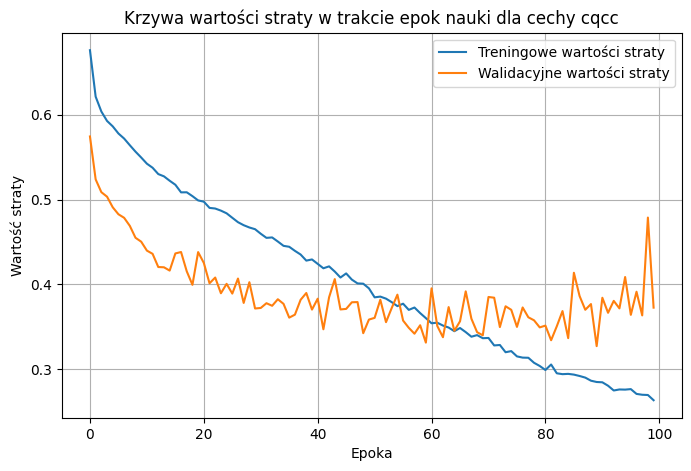

Final Accuracy: 0.8664 | F1 Score: 0.8601 | EER: 0.1339
Final Accuracy: 0.8559 | F1 Score: 0.8405 | EER: 0.1354
Zapisano modele i wyniki dla 'cqcc' → AdamW_CrossEntropyLoss_lr0.0001_wd0.0001
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.0001_wd0.0001\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6898 | Train Acc: 0.5395 | Val Loss: 0.6594 | Val Acc: 0.6667
[gtcc] Epoch 2/100 | Train Loss: 0.6506 | Train Acc: 0.6212 | Val Loss: 0.5499 | Val Acc: 0.7686
[gtcc] Epoch 3/100 | Train Loss: 0.6210 | Train Acc: 0.6563 | Val Loss: 0.5357 | Val Acc: 0.7682
[gtcc] Epoch 4/100 | Train Loss: 0.6037 | Train Acc: 0.6682 | Val Loss: 0.5152 | Val Acc: 0.7761
[gtcc] Epoch 5/100 | Train Loss: 0.5930 | Train Acc: 0.6723 | Val Loss: 0.5053 | Val Acc: 0.7746
[gtcc] Epoch 6/100 | Train Loss: 0.5918 | Train Acc: 0.6736 | Val Loss: 0.5041 | Val Acc: 0.7713
[gtcc] Epoch 7/100 | Train Loss: 0.5848 | Train Acc: 0.6754 | Val Loss: 0.4943 | Val Acc: 0

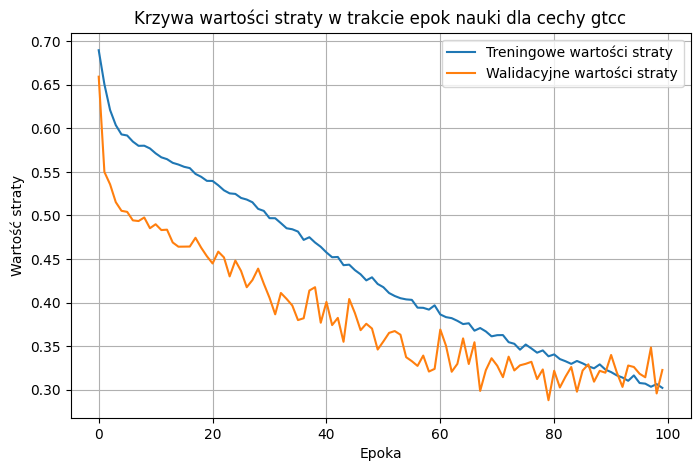

Final Accuracy: 0.8822 | F1 Score: 0.8750 | EER: 0.1159
Final Accuracy: 0.8683 | F1 Score: 0.8539 | EER: 0.1121
Zapisano modele i wyniki dla 'gtcc' → AdamW_CrossEntropyLoss_lr0.0001_wd0.0001
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.0001_wd0.0001\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6676 | Train Acc: 0.5855 | Val Loss: 0.6096 | Val Acc: 0.6911
[mel-spect] Epoch 2/100 | Train Loss: 0.6113 | Train Acc: 0.6568 | Val Loss: 0.4991 | Val Acc: 0.7788
[mel-spect] Epoch 3/100 | Train Loss: 0.5854 | Train Acc: 0.6690 | Val Loss: 0.4830 | Val Acc: 0.7780
[mel-spect] Epoch 4/100 | Train Loss: 0.5760 | Train Acc: 0.6727 | Val Loss: 0.4759 | Val Acc: 0.7825
[mel-spect] Epoch 5/100 | Train Loss: 0.5678 | Train Acc: 0.6780 | Val Loss: 0.4787 | Val Acc: 0.7792
[mel-spect] Epoch 6/100 | Train Loss: 0.5669 | Train Acc: 0.6791 | Val Loss: 0.4780 | Val Acc: 0.7735
[mel-spect] Epoch 7/100 | Train Loss: 0.5629 | Train Acc

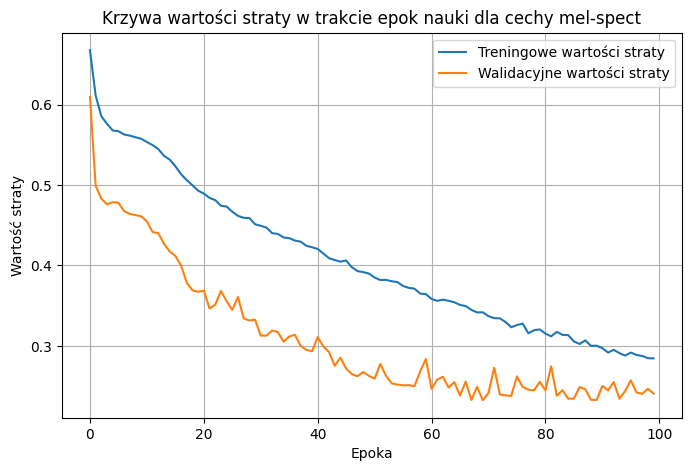

Final Accuracy: 0.9108 | F1 Score: 0.9083 | EER: 0.0926
Final Accuracy: 0.9195 | F1 Score: 0.9171 | EER: 0.0828
Zapisano modele i wyniki dla 'mel-spect' → AdamW_CrossEntropyLoss_lr0.0001_wd0.0001
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.0001_wd0.0001\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6506 | Train Acc: 0.6229 | Val Loss: 0.5630 | Val Acc: 0.7611
[mfcc] Epoch 2/100 | Train Loss: 0.6066 | Train Acc: 0.6708 | Val Loss: 0.5116 | Val Acc: 0.7803
[mfcc] Epoch 3/100 | Train Loss: 0.5910 | Train Acc: 0.6734 | Val Loss: 0.4978 | Val Acc: 0.7859
[mfcc] Epoch 4/100 | Train Loss: 0.5806 | Train Acc: 0.6771 | Val Loss: 0.4781 | Val Acc: 0.7818
[mfcc] Epoch 5/100 | Train Loss: 0.5733 | Train Acc: 0.6805 | Val Loss: 0.4640 | Val Acc: 0.7874
[mfcc] Epoch 6/100 | Train Loss: 0.5658 | Train Acc: 0.6776 | Val Loss: 0.4533 | Val Acc: 0.7871
[mfcc] Epoch 7/100 | Train Loss: 0.5582 | Train Acc: 0.6846 | Val Loss: 0.43

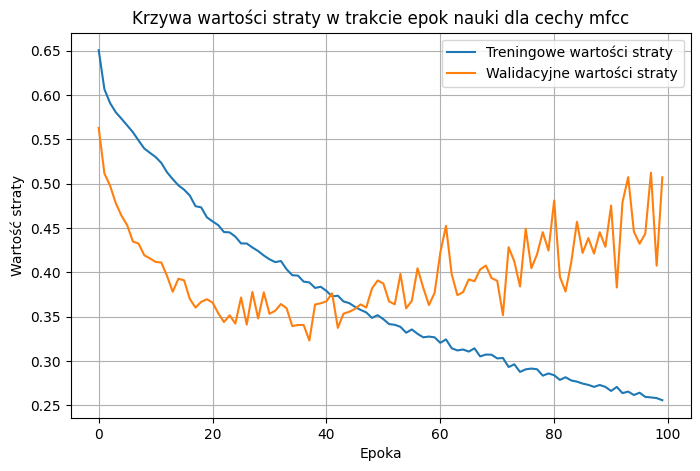

Final Accuracy: 0.8612 | F1 Score: 0.8499 | EER: 0.1362
Final Accuracy: 0.8473 | F1 Score: 0.8252 | EER: 0.1189
Zapisano modele i wyniki dla 'mfcc' → AdamW_CrossEntropyLoss_lr0.0001_wd0.0001
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.0001_wd0.0001\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6595 | Train Acc: 0.5948 | Val Loss: 0.5817 | Val Acc: 0.7543
[lfcc] Epoch 2/100 | Train Loss: 0.6142 | Train Acc: 0.6590 | Val Loss: 0.5488 | Val Acc: 0.7641
[lfcc] Epoch 3/100 | Train Loss: 0.5990 | Train Acc: 0.6679 | Val Loss: 0.5297 | Val Acc: 0.7690
[lfcc] Epoch 4/100 | Train Loss: 0.5877 | Train Acc: 0.6759 | Val Loss: 0.5246 | Val Acc: 0.7713
[lfcc] Epoch 5/100 | Train Loss: 0.5846 | Train Acc: 0.6765 | Val Loss: 0.5152 | Val Acc: 0.7754
[lfcc] Epoch 6/100 | Train Loss: 0.5813 | Train Acc: 0.6769 | Val Loss: 0.5072 | Val Acc: 0.7788
[lfcc] Epoch 7/100 | Train Loss: 0.5762 | Train Acc: 0.6821 | Val Loss: 0.4978 | Val Acc: 0

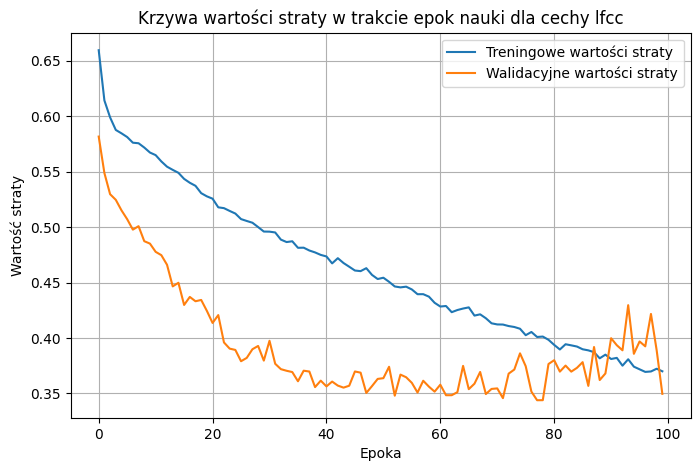

Final Accuracy: 0.8597 | F1 Score: 0.8550 | EER: 0.1415
Final Accuracy: 0.8525 | F1 Score: 0.8444 | EER: 0.1445
Zapisano modele i wyniki dla 'lfcc' → AdamW_CrossEntropyLoss_lr0.0001_wd0.0001
Folder: Res_Net\AdamW_CrossEntropyLoss_lr0.0001_wd0.0001\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla AdamW_CrossEntropyLoss_lr0.0001_wd0.0001 ==========


========== Trening z SGD_CrossEntropyLoss_lr0.001_mom0.9_wd1e-05 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6938 | Train Acc: 0.5053 | Val Loss: 0.6833 | Val Acc: 0.7111
[cqcc] Epoch 2/100 | Train Loss: 0.6868 | Train Acc: 0.5439 | Val Loss: 0.6483 | Val Acc: 0.7378
[cqcc] Epoch 3/100 | Train Loss: 0.6651 | Train Acc: 0.6034 | Val Loss: 0.6207 | Val Acc: 0.6813
[cqcc] Epoch 4/100 | Train Loss: 0.6466 | Train Acc: 0.6292 | Val Loss: 0.6080 | Val Acc: 0.6618
[cqcc] Epoch 5/100 | Train Loss: 0.6352 | Train Acc: 0.6456 | Val Loss: 0.5642 | Val Acc: 0.7197
[cqcc] Epoch 6/100 | Train 

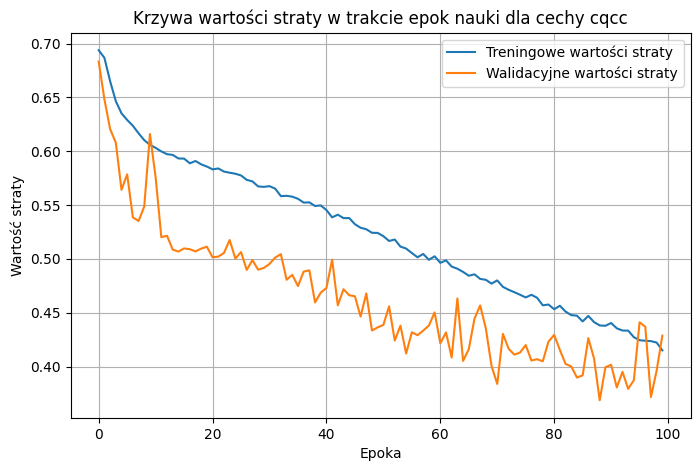

Final Accuracy: 0.8375 | F1 Score: 0.8191 | EER: 0.1415
Final Accuracy: 0.8074 | F1 Score: 0.7710 | EER: 0.1475
Zapisano modele i wyniki dla 'cqcc' → SGD_CrossEntropyLoss_lr0.001_mom0.9_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.9_wd1e-05\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6950 | Train Acc: 0.5192 | Val Loss: 0.6866 | Val Acc: 0.5150
[gtcc] Epoch 2/100 | Train Loss: 0.6847 | Train Acc: 0.5762 | Val Loss: 0.6583 | Val Acc: 0.6851
[gtcc] Epoch 3/100 | Train Loss: 0.6659 | Train Acc: 0.6217 | Val Loss: 0.6082 | Val Acc: 0.7577
[gtcc] Epoch 4/100 | Train Loss: 0.6492 | Train Acc: 0.6335 | Val Loss: 0.5767 | Val Acc: 0.7637
[gtcc] Epoch 5/100 | Train Loss: 0.6339 | Train Acc: 0.6476 | Val Loss: 0.5527 | Val Acc: 0.7739
[gtcc] Epoch 6/100 | Train Loss: 0.6238 | Train Acc: 0.6603 | Val Loss: 0.5441 | Val Acc: 0.7705
[gtcc] Epoch 7/100 | Train Loss: 0.6161 | Train Acc: 0.6626 | Val Loss: 0.5340 | Val 

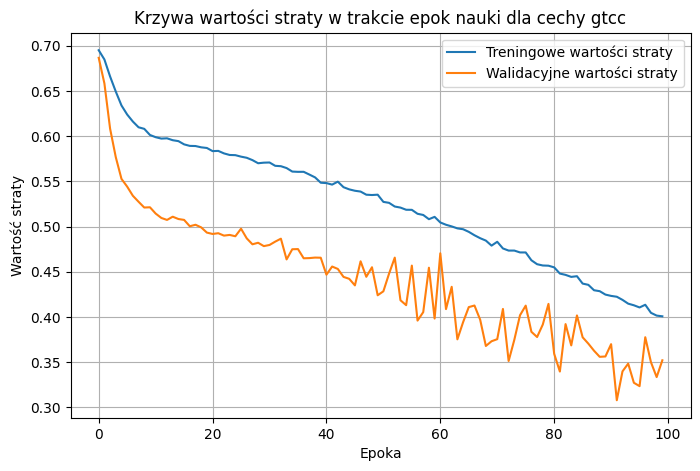

Final Accuracy: 0.8638 | F1 Score: 0.8543 | EER: 0.1249
Final Accuracy: 0.8465 | F1 Score: 0.8291 | EER: 0.1339
Zapisano modele i wyniki dla 'gtcc' → SGD_CrossEntropyLoss_lr0.001_mom0.9_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.9_wd1e-05\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6855 | Train Acc: 0.5408 | Val Loss: 0.6491 | Val Acc: 0.7306
[mel-spect] Epoch 2/100 | Train Loss: 0.6558 | Train Acc: 0.6060 | Val Loss: 0.5730 | Val Acc: 0.7686
[mel-spect] Epoch 3/100 | Train Loss: 0.6297 | Train Acc: 0.6427 | Val Loss: 0.5409 | Val Acc: 0.7731
[mel-spect] Epoch 4/100 | Train Loss: 0.6127 | Train Acc: 0.6582 | Val Loss: 0.5028 | Val Acc: 0.7859
[mel-spect] Epoch 5/100 | Train Loss: 0.5979 | Train Acc: 0.6639 | Val Loss: 0.4804 | Val Acc: 0.7822
[mel-spect] Epoch 6/100 | Train Loss: 0.5856 | Train Acc: 0.6746 | Val Loss: 0.4838 | Val Acc: 0.7840
[mel-spect] Epoch 7/100 | Train Loss: 0.5821 | Tra

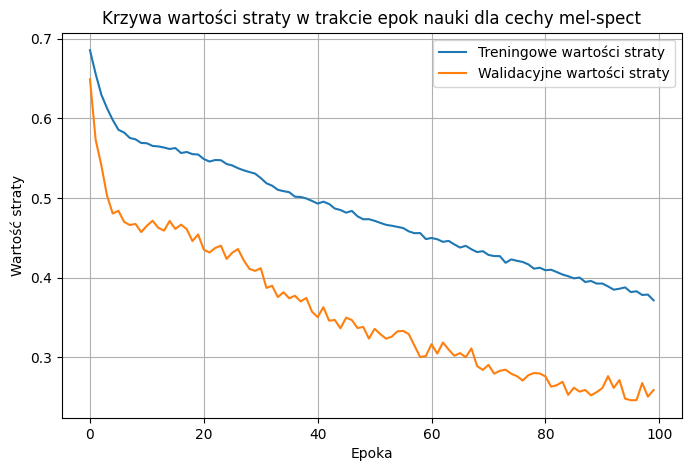

Final Accuracy: 0.9041 | F1 Score: 0.9018 | EER: 0.0910
Final Accuracy: 0.8988 | F1 Score: 0.8964 | EER: 0.0993
Zapisano modele i wyniki dla 'mel-spect' → SGD_CrossEntropyLoss_lr0.001_mom0.9_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.9_wd1e-05\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6666 | Train Acc: 0.5959 | Val Loss: 0.5972 | Val Acc: 0.7397
[mfcc] Epoch 2/100 | Train Loss: 0.6334 | Train Acc: 0.6438 | Val Loss: 0.5603 | Val Acc: 0.7660
[mfcc] Epoch 3/100 | Train Loss: 0.6204 | Train Acc: 0.6574 | Val Loss: 0.5383 | Val Acc: 0.7773
[mfcc] Epoch 4/100 | Train Loss: 0.6073 | Train Acc: 0.6674 | Val Loss: 0.5238 | Val Acc: 0.7799
[mfcc] Epoch 5/100 | Train Loss: 0.6014 | Train Acc: 0.6705 | Val Loss: 0.5179 | Val Acc: 0.7773
[mfcc] Epoch 6/100 | Train Loss: 0.5942 | Train Acc: 0.6743 | Val Loss: 0.5058 | Val Acc: 0.7799
[mfcc] Epoch 7/100 | Train Loss: 0.5885 | Train Acc: 0.6808 | Val Loss

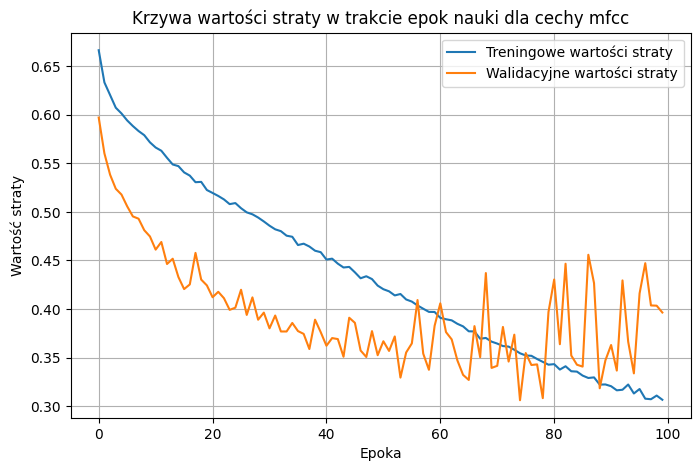

Final Accuracy: 0.8713 | F1 Score: 0.8611 | EER: 0.1242
Final Accuracy: 0.8457 | F1 Score: 0.8255 | EER: 0.1226
Zapisano modele i wyniki dla 'mfcc' → SGD_CrossEntropyLoss_lr0.001_mom0.9_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.9_wd1e-05\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6798 | Train Acc: 0.5503 | Val Loss: 0.6703 | Val Acc: 0.5910
[lfcc] Epoch 2/100 | Train Loss: 0.6660 | Train Acc: 0.5863 | Val Loss: 0.6486 | Val Acc: 0.6674
[lfcc] Epoch 3/100 | Train Loss: 0.6579 | Train Acc: 0.5935 | Val Loss: 0.6502 | Val Acc: 0.6211
[lfcc] Epoch 4/100 | Train Loss: 0.6456 | Train Acc: 0.6109 | Val Loss: 0.6292 | Val Acc: 0.6433
[lfcc] Epoch 5/100 | Train Loss: 0.6321 | Train Acc: 0.6305 | Val Loss: 0.6318 | Val Acc: 0.6257
[lfcc] Epoch 6/100 | Train Loss: 0.6217 | Train Acc: 0.6467 | Val Loss: 0.6133 | Val Acc: 0.6569
[lfcc] Epoch 7/100 | Train Loss: 0.6128 | Train Acc: 0.6543 | Val Loss: 0.5919 | Val 

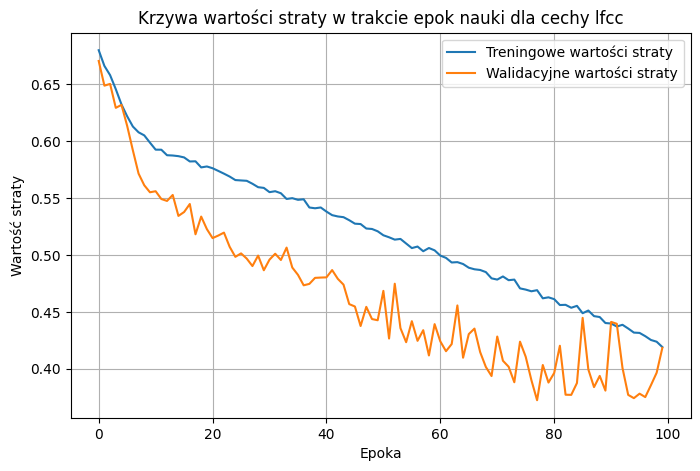

Final Accuracy: 0.8299 | F1 Score: 0.8163 | EER: 0.1701
Final Accuracy: 0.8164 | F1 Score: 0.7867 | EER: 0.1550
Zapisano modele i wyniki dla 'lfcc' → SGD_CrossEntropyLoss_lr0.001_mom0.9_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.9_wd1e-05\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla SGD_CrossEntropyLoss_lr0.001_mom0.9_wd1e-05 ==========


========== Trening z SGD_CrossEntropyLoss_lr0.001_mom0.95_wd1e-05 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6937 | Train Acc: 0.5110 | Val Loss: 0.6749 | Val Acc: 0.7265
[cqcc] Epoch 2/100 | Train Loss: 0.6721 | Train Acc: 0.5772 | Val Loss: 0.5854 | Val Acc: 0.7269
[cqcc] Epoch 3/100 | Train Loss: 0.6428 | Train Acc: 0.6302 | Val Loss: 0.5724 | Val Acc: 0.7389
[cqcc] Epoch 4/100 | Train Loss: 0.6233 | Train Acc: 0.6573 | Val Loss: 0.5465 | Val Acc: 0.7713
[cqcc] Epoch 5/100 | Train Loss: 0.6094 | Train Acc: 0.6714 | Val Loss: 0.5147 | Val Acc: 0.7746
[cqcc] Epoch 6/10

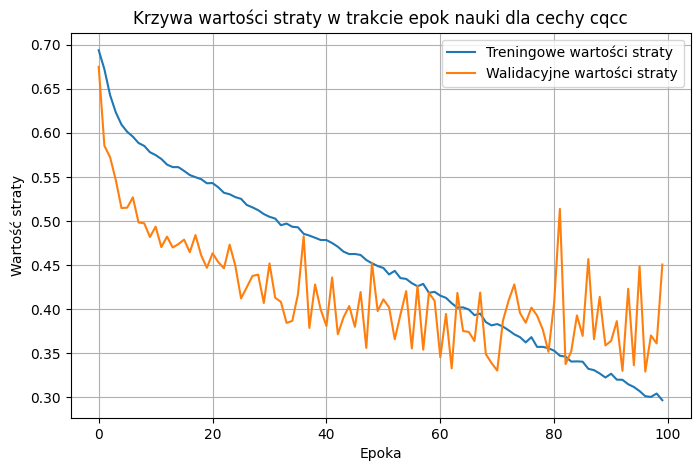

Final Accuracy: 0.8627 | F1 Score: 0.8551 | EER: 0.1324
Final Accuracy: 0.8093 | F1 Score: 0.7750 | EER: 0.1377
Zapisano modele i wyniki dla 'cqcc' → SGD_CrossEntropyLoss_lr0.001_mom0.95_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.95_wd1e-05\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6924 | Train Acc: 0.5350 | Val Loss: 0.6674 | Val Acc: 0.6535
[gtcc] Epoch 2/100 | Train Loss: 0.6656 | Train Acc: 0.6119 | Val Loss: 0.6015 | Val Acc: 0.7333
[gtcc] Epoch 3/100 | Train Loss: 0.6380 | Train Acc: 0.6422 | Val Loss: 0.5568 | Val Acc: 0.7667
[gtcc] Epoch 4/100 | Train Loss: 0.6170 | Train Acc: 0.6625 | Val Loss: 0.5418 | Val Acc: 0.7660
[gtcc] Epoch 5/100 | Train Loss: 0.6092 | Train Acc: 0.6655 | Val Loss: 0.5225 | Val Acc: 0.7690
[gtcc] Epoch 6/100 | Train Loss: 0.6002 | Train Acc: 0.6721 | Val Loss: 0.5137 | Val Acc: 0.7694
[gtcc] Epoch 7/100 | Train Loss: 0.5982 | Train Acc: 0.6704 | Val Loss: 0.5218 | Va

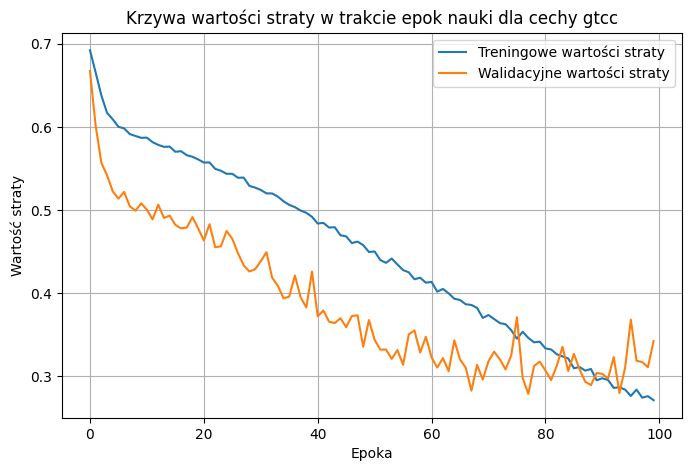

Final Accuracy: 0.8841 | F1 Score: 0.8786 | EER: 0.1166
Final Accuracy: 0.8627 | F1 Score: 0.8491 | EER: 0.1242
Zapisano modele i wyniki dla 'gtcc' → SGD_CrossEntropyLoss_lr0.001_mom0.95_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.95_wd1e-05\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6720 | Train Acc: 0.5733 | Val Loss: 0.6168 | Val Acc: 0.6561
[mel-spect] Epoch 2/100 | Train Loss: 0.6275 | Train Acc: 0.6485 | Val Loss: 0.5251 | Val Acc: 0.7769
[mel-spect] Epoch 3/100 | Train Loss: 0.6014 | Train Acc: 0.6606 | Val Loss: 0.5083 | Val Acc: 0.7728
[mel-spect] Epoch 4/100 | Train Loss: 0.5885 | Train Acc: 0.6664 | Val Loss: 0.4851 | Val Acc: 0.7773
[mel-spect] Epoch 5/100 | Train Loss: 0.5786 | Train Acc: 0.6751 | Val Loss: 0.4803 | Val Acc: 0.7713
[mel-spect] Epoch 6/100 | Train Loss: 0.5776 | Train Acc: 0.6737 | Val Loss: 0.4790 | Val Acc: 0.7754
[mel-spect] Epoch 7/100 | Train Loss: 0.5728 | T

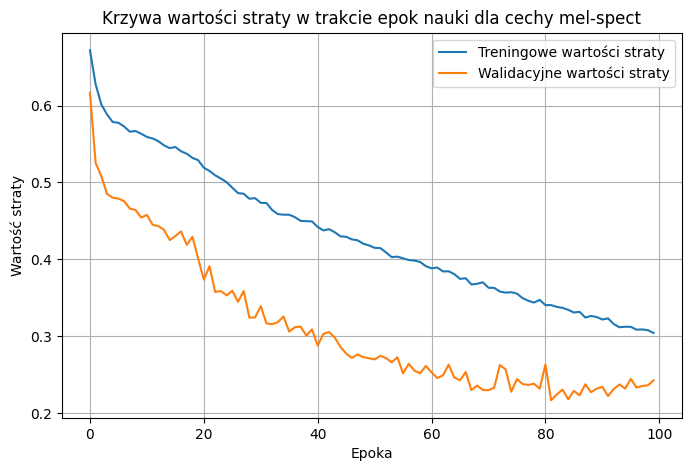

Final Accuracy: 0.9195 | F1 Score: 0.9171 | EER: 0.0783
Final Accuracy: 0.9165 | F1 Score: 0.9150 | EER: 0.0775
Zapisano modele i wyniki dla 'mel-spect' → SGD_CrossEntropyLoss_lr0.001_mom0.95_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.95_wd1e-05\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6588 | Train Acc: 0.6059 | Val Loss: 0.5794 | Val Acc: 0.7675
[mfcc] Epoch 2/100 | Train Loss: 0.6171 | Train Acc: 0.6633 | Val Loss: 0.5329 | Val Acc: 0.7750
[mfcc] Epoch 3/100 | Train Loss: 0.6001 | Train Acc: 0.6741 | Val Loss: 0.5094 | Val Acc: 0.7814
[mfcc] Epoch 4/100 | Train Loss: 0.5940 | Train Acc: 0.6752 | Val Loss: 0.5060 | Val Acc: 0.7795
[mfcc] Epoch 5/100 | Train Loss: 0.5867 | Train Acc: 0.6757 | Val Loss: 0.5034 | Val Acc: 0.7856
[mfcc] Epoch 6/100 | Train Loss: 0.5782 | Train Acc: 0.6828 | Val Loss: 0.4961 | Val Acc: 0.7814
[mfcc] Epoch 7/100 | Train Loss: 0.5713 | Train Acc: 0.6824 | Val Lo

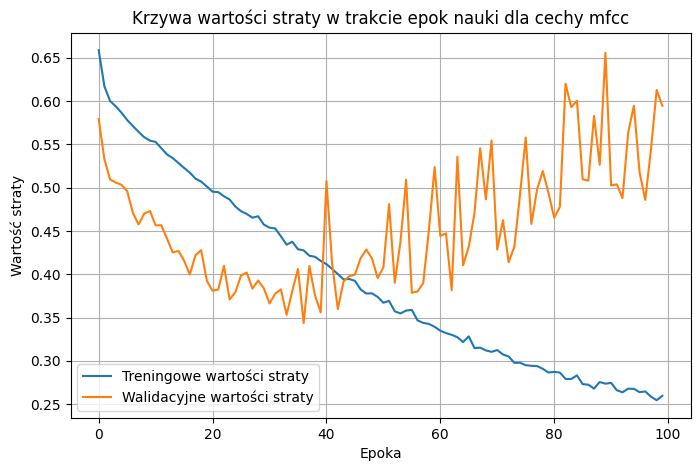

Final Accuracy: 0.8529 | F1 Score: 0.8369 | EER: 0.1287
Final Accuracy: 0.8190 | F1 Score: 0.7836 | EER: 0.1272
Zapisano modele i wyniki dla 'mfcc' → SGD_CrossEntropyLoss_lr0.001_mom0.95_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.95_wd1e-05\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6775 | Train Acc: 0.5620 | Val Loss: 0.6596 | Val Acc: 0.6234
[lfcc] Epoch 2/100 | Train Loss: 0.6584 | Train Acc: 0.5946 | Val Loss: 0.6347 | Val Acc: 0.6520
[lfcc] Epoch 3/100 | Train Loss: 0.6425 | Train Acc: 0.6142 | Val Loss: 0.6164 | Val Acc: 0.6554
[lfcc] Epoch 4/100 | Train Loss: 0.6237 | Train Acc: 0.6459 | Val Loss: 0.5799 | Val Acc: 0.6956
[lfcc] Epoch 5/100 | Train Loss: 0.6074 | Train Acc: 0.6584 | Val Loss: 0.5585 | Val Acc: 0.7325
[lfcc] Epoch 6/100 | Train Loss: 0.5961 | Train Acc: 0.6671 | Val Loss: 0.5368 | Val Acc: 0.7555
[lfcc] Epoch 7/100 | Train Loss: 0.5921 | Train Acc: 0.6665 | Val Loss: 0.5544 | Va

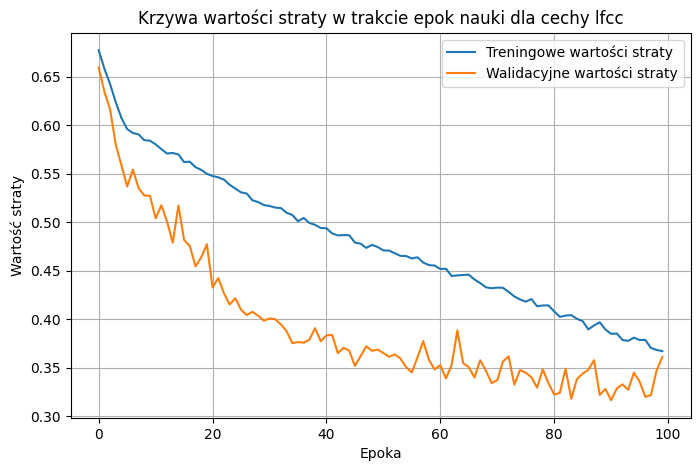

Final Accuracy: 0.8631 | F1 Score: 0.8533 | EER: 0.1257
Final Accuracy: 0.8540 | F1 Score: 0.8377 | EER: 0.1354
Zapisano modele i wyniki dla 'lfcc' → SGD_CrossEntropyLoss_lr0.001_mom0.95_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.95_wd1e-05\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla SGD_CrossEntropyLoss_lr0.001_mom0.95_wd1e-05 ==========


========== Trening z SGD_CrossEntropyLoss_lr0.001_mom0.9_wd0.0001 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6942 | Train Acc: 0.5107 | Val Loss: 0.6838 | Val Acc: 0.5147
[cqcc] Epoch 2/100 | Train Loss: 0.6781 | Train Acc: 0.5633 | Val Loss: 0.6313 | Val Acc: 0.7340
[cqcc] Epoch 3/100 | Train Loss: 0.6513 | Train Acc: 0.6181 | Val Loss: 0.5812 | Val Acc: 0.7746
[cqcc] Epoch 4/100 | Train Loss: 0.6304 | Train Acc: 0.6486 | Val Loss: 0.5501 | Val Acc: 0.7746
[cqcc] Epoch 5/100 | Train Loss: 0.6192 | Train Acc: 0.6596 | Val Loss: 0.5388 | Val Acc: 0.7735
[cqcc] Epoch 6

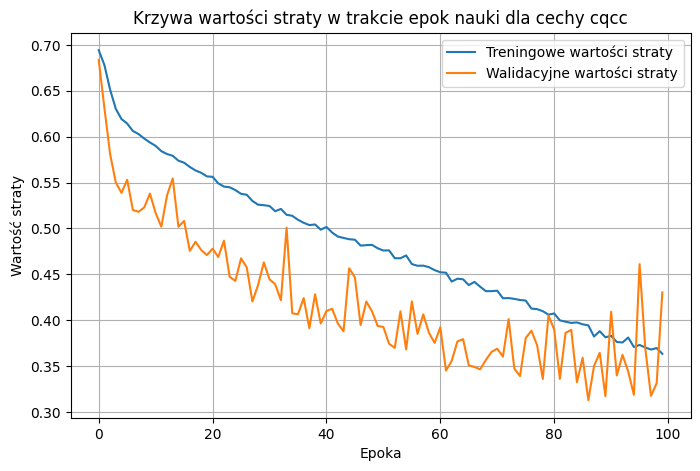

Final Accuracy: 0.8713 | F1 Score: 0.8671 | EER: 0.1347
Final Accuracy: 0.8085 | F1 Score: 0.7719 | EER: 0.1279
Zapisano modele i wyniki dla 'cqcc' → SGD_CrossEntropyLoss_lr0.001_mom0.9_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.9_wd0.0001\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6974 | Train Acc: 0.5018 | Val Loss: 0.6919 | Val Acc: 0.5030
[gtcc] Epoch 2/100 | Train Loss: 0.6931 | Train Acc: 0.5288 | Val Loss: 0.6891 | Val Acc: 0.5489
[gtcc] Epoch 3/100 | Train Loss: 0.6896 | Train Acc: 0.5551 | Val Loss: 0.6822 | Val Acc: 0.6260
[gtcc] Epoch 4/100 | Train Loss: 0.6855 | Train Acc: 0.5667 | Val Loss: 0.6686 | Val Acc: 0.6757
[gtcc] Epoch 5/100 | Train Loss: 0.6772 | Train Acc: 0.5825 | Val Loss: 0.6534 | Val Acc: 0.6764
[gtcc] Epoch 6/100 | Train Loss: 0.6670 | Train Acc: 0.5977 | Val Loss: 0.6327 | Val Acc: 0.6971
[gtcc] Epoch 7/100 | Train Loss: 0.6566 | Train Acc: 0.6088 | Val Loss: 0.6160 | Va

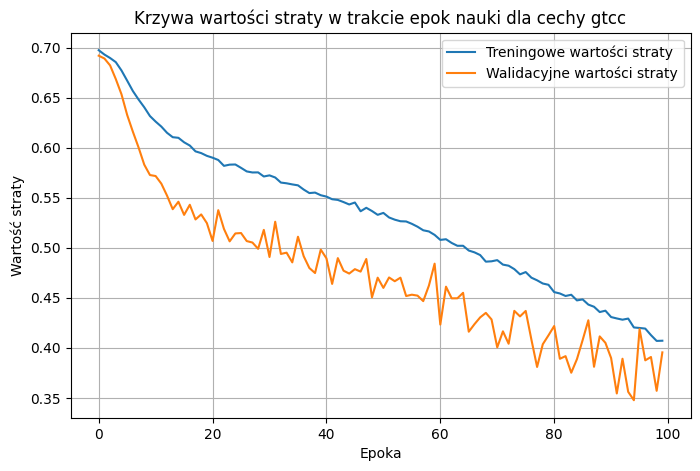

Final Accuracy: 0.8427 | F1 Score: 0.8273 | EER: 0.1437
Final Accuracy: 0.8269 | F1 Score: 0.7982 | EER: 0.1535
Zapisano modele i wyniki dla 'gtcc' → SGD_CrossEntropyLoss_lr0.001_mom0.9_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.9_wd0.0001\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6855 | Train Acc: 0.5399 | Val Loss: 0.6459 | Val Acc: 0.6546
[mel-spect] Epoch 2/100 | Train Loss: 0.6497 | Train Acc: 0.6176 | Val Loss: 0.5839 | Val Acc: 0.7536
[mel-spect] Epoch 3/100 | Train Loss: 0.6223 | Train Acc: 0.6492 | Val Loss: 0.5325 | Val Acc: 0.7765
[mel-spect] Epoch 4/100 | Train Loss: 0.6111 | Train Acc: 0.6550 | Val Loss: 0.5168 | Val Acc: 0.7810
[mel-spect] Epoch 5/100 | Train Loss: 0.5970 | Train Acc: 0.6652 | Val Loss: 0.4989 | Val Acc: 0.7844
[mel-spect] Epoch 6/100 | Train Loss: 0.5927 | Train Acc: 0.6693 | Val Loss: 0.4872 | Val Acc: 0.7792
[mel-spect] Epoch 7/100 | Train Loss: 0.5846 | T

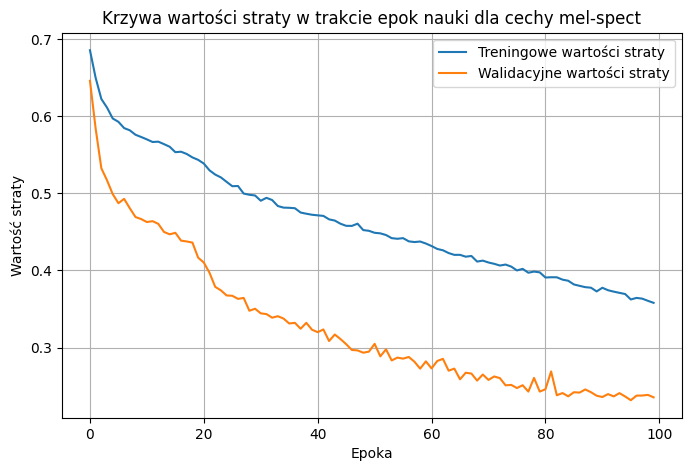

Final Accuracy: 0.9112 | F1 Score: 0.9085 | EER: 0.0986
Final Accuracy: 0.9063 | F1 Score: 0.9057 | EER: 0.0963
Zapisano modele i wyniki dla 'mel-spect' → SGD_CrossEntropyLoss_lr0.001_mom0.9_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.9_wd0.0001\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6759 | Train Acc: 0.5805 | Val Loss: 0.6514 | Val Acc: 0.6200
[mfcc] Epoch 2/100 | Train Loss: 0.6439 | Train Acc: 0.6509 | Val Loss: 0.6600 | Val Acc: 0.5474
[mfcc] Epoch 3/100 | Train Loss: 0.6271 | Train Acc: 0.6542 | Val Loss: 0.5842 | Val Acc: 0.7216
[mfcc] Epoch 4/100 | Train Loss: 0.6156 | Train Acc: 0.6646 | Val Loss: 0.5658 | Val Acc: 0.7344
[mfcc] Epoch 5/100 | Train Loss: 0.6085 | Train Acc: 0.6694 | Val Loss: 0.5470 | Val Acc: 0.7607
[mfcc] Epoch 6/100 | Train Loss: 0.6017 | Train Acc: 0.6720 | Val Loss: 0.5442 | Val Acc: 0.7641
[mfcc] Epoch 7/100 | Train Loss: 0.5985 | Train Acc: 0.6704 | Val Lo

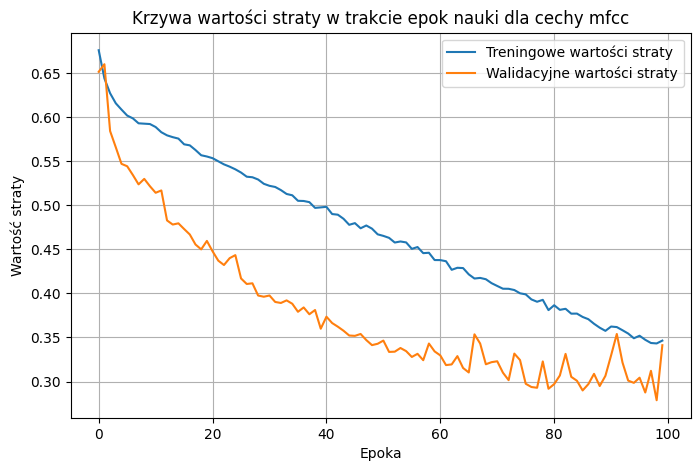

Final Accuracy: 0.8826 | F1 Score: 0.8763 | EER: 0.1121
Final Accuracy: 0.8578 | F1 Score: 0.8420 | EER: 0.1249
Zapisano modele i wyniki dla 'mfcc' → SGD_CrossEntropyLoss_lr0.001_mom0.9_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.9_wd0.0001\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6815 | Train Acc: 0.5453 | Val Loss: 0.6591 | Val Acc: 0.6798
[lfcc] Epoch 2/100 | Train Loss: 0.6619 | Train Acc: 0.5936 | Val Loss: 0.6284 | Val Acc: 0.6561
[lfcc] Epoch 3/100 | Train Loss: 0.6374 | Train Acc: 0.6336 | Val Loss: 0.5766 | Val Acc: 0.7562
[lfcc] Epoch 4/100 | Train Loss: 0.6169 | Train Acc: 0.6530 | Val Loss: 0.5591 | Val Acc: 0.7667
[lfcc] Epoch 5/100 | Train Loss: 0.6076 | Train Acc: 0.6597 | Val Loss: 0.5547 | Val Acc: 0.7626
[lfcc] Epoch 6/100 | Train Loss: 0.6018 | Train Acc: 0.6688 | Val Loss: 0.5422 | Val Acc: 0.7701
[lfcc] Epoch 7/100 | Train Loss: 0.5979 | Train Acc: 0.6666 | Val Loss: 0.5250 | Va

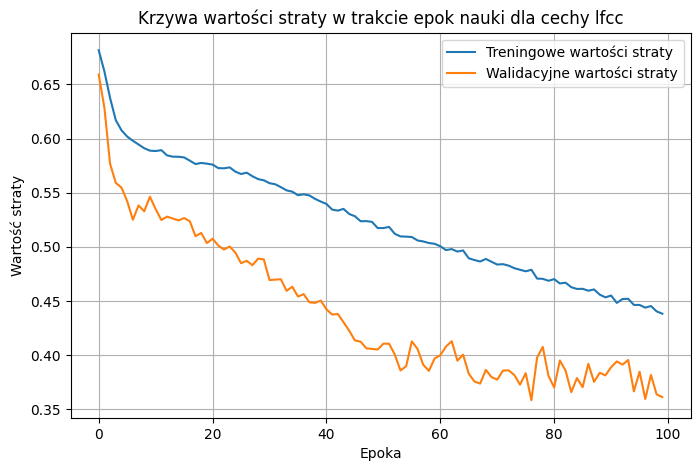

Final Accuracy: 0.8457 | F1 Score: 0.8412 | EER: 0.1482
Final Accuracy: 0.8337 | F1 Score: 0.8205 | EER: 0.1445
Zapisano modele i wyniki dla 'lfcc' → SGD_CrossEntropyLoss_lr0.001_mom0.9_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.9_wd0.0001\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla SGD_CrossEntropyLoss_lr0.001_mom0.9_wd0.0001 ==========


========== Trening z SGD_CrossEntropyLoss_lr0.001_mom0.95_wd0.0001 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6956 | Train Acc: 0.5052 | Val Loss: 0.6923 | Val Acc: 0.5000
[cqcc] Epoch 2/100 | Train Loss: 0.6922 | Train Acc: 0.5192 | Val Loss: 0.6856 | Val Acc: 0.5000
[cqcc] Epoch 3/100 | Train Loss: 0.6734 | Train Acc: 0.5806 | Val Loss: 0.7006 | Val Acc: 0.5000
[cqcc] Epoch 4/100 | Train Loss: 0.6409 | Train Acc: 0.6377 | Val Loss: 0.5816 | Val Acc: 0.7133
[cqcc] Epoch 5/100 | Train Loss: 0.6265 | Train Acc: 0.6573 | Val Loss: 0.5303 | Val Acc: 0.7758
[cqcc] Epoch 

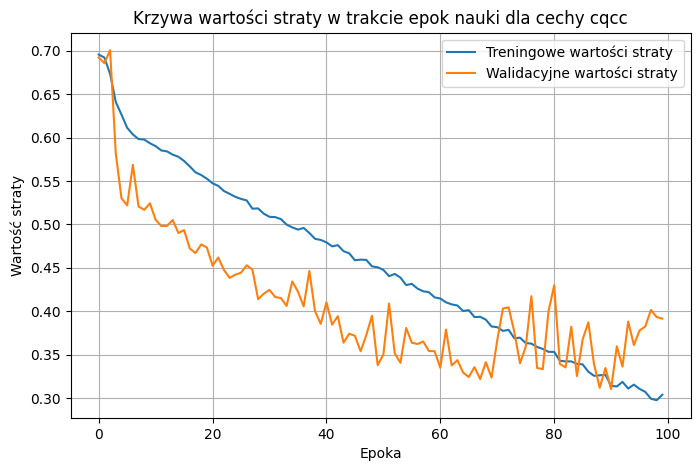

Final Accuracy: 0.8762 | F1 Score: 0.8702 | EER: 0.1264
Final Accuracy: 0.8367 | F1 Score: 0.8134 | EER: 0.1196
Zapisano modele i wyniki dla 'cqcc' → SGD_CrossEntropyLoss_lr0.001_mom0.95_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.95_wd0.0001\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6947 | Train Acc: 0.5210 | Val Loss: 0.6866 | Val Acc: 0.5771
[gtcc] Epoch 2/100 | Train Loss: 0.6869 | Train Acc: 0.5703 | Val Loss: 0.6640 | Val Acc: 0.6633
[gtcc] Epoch 3/100 | Train Loss: 0.6677 | Train Acc: 0.6050 | Val Loss: 0.5927 | Val Acc: 0.7502
[gtcc] Epoch 4/100 | Train Loss: 0.6387 | Train Acc: 0.6428 | Val Loss: 0.5570 | Val Acc: 0.7656
[gtcc] Epoch 5/100 | Train Loss: 0.6231 | Train Acc: 0.6587 | Val Loss: 0.5385 | Val Acc: 0.7686
[gtcc] Epoch 6/100 | Train Loss: 0.6120 | Train Acc: 0.6626 | Val Loss: 0.5247 | Val Acc: 0.7694
[gtcc] Epoch 7/100 | Train Loss: 0.6049 | Train Acc: 0.6712 | Val Loss: 0.5146 | 

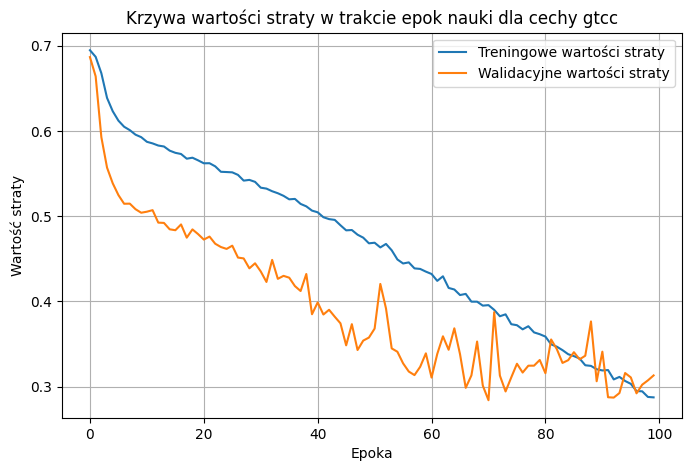

Final Accuracy: 0.8815 | F1 Score: 0.8768 | EER: 0.1242
Final Accuracy: 0.8691 | F1 Score: 0.8549 | EER: 0.1159
Zapisano modele i wyniki dla 'gtcc' → SGD_CrossEntropyLoss_lr0.001_mom0.95_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.95_wd0.0001\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6564 | Train Acc: 0.5968 | Val Loss: 0.5623 | Val Acc: 0.7652
[mel-spect] Epoch 2/100 | Train Loss: 0.6141 | Train Acc: 0.6600 | Val Loss: 0.5286 | Val Acc: 0.7739
[mel-spect] Epoch 3/100 | Train Loss: 0.5953 | Train Acc: 0.6707 | Val Loss: 0.4997 | Val Acc: 0.7773
[mel-spect] Epoch 4/100 | Train Loss: 0.5821 | Train Acc: 0.6705 | Val Loss: 0.4887 | Val Acc: 0.7799
[mel-spect] Epoch 5/100 | Train Loss: 0.5761 | Train Acc: 0.6734 | Val Loss: 0.4718 | Val Acc: 0.7799
[mel-spect] Epoch 6/100 | Train Loss: 0.5694 | Train Acc: 0.6776 | Val Loss: 0.4645 | Val Acc: 0.7810
[mel-spect] Epoch 7/100 | Train Loss: 0.5649 |

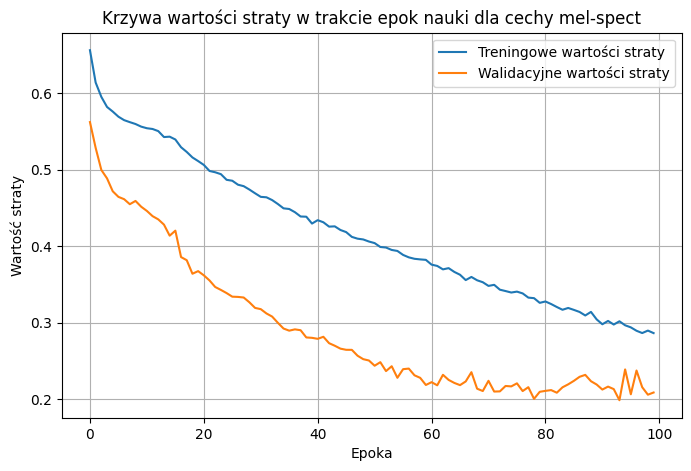

Final Accuracy: 0.9278 | F1 Score: 0.9260 | EER: 0.0813
Final Accuracy: 0.9229 | F1 Score: 0.9227 | EER: 0.0760
Zapisano modele i wyniki dla 'mel-spect' → SGD_CrossEntropyLoss_lr0.001_mom0.95_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.95_wd0.0001\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6541 | Train Acc: 0.6187 | Val Loss: 0.6061 | Val Acc: 0.6859
[mfcc] Epoch 2/100 | Train Loss: 0.6235 | Train Acc: 0.6589 | Val Loss: 0.5869 | Val Acc: 0.7043
[mfcc] Epoch 3/100 | Train Loss: 0.6117 | Train Acc: 0.6634 | Val Loss: 0.5347 | Val Acc: 0.7667
[mfcc] Epoch 4/100 | Train Loss: 0.6031 | Train Acc: 0.6690 | Val Loss: 0.5201 | Val Acc: 0.7701
[mfcc] Epoch 5/100 | Train Loss: 0.5966 | Train Acc: 0.6690 | Val Loss: 0.5068 | Val Acc: 0.7750
[mfcc] Epoch 6/100 | Train Loss: 0.5913 | Train Acc: 0.6729 | Val Loss: 0.4978 | Val Acc: 0.7758
[mfcc] Epoch 7/100 | Train Loss: 0.5840 | Train Acc: 0.6753 | Val 

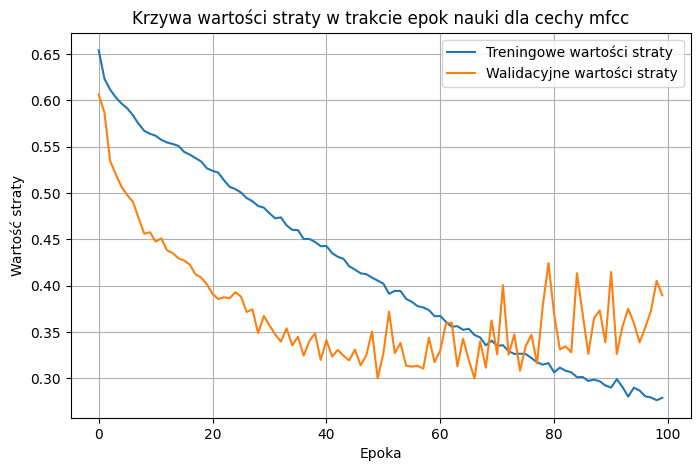

Final Accuracy: 0.8725 | F1 Score: 0.8649 | EER: 0.1211
Final Accuracy: 0.8619 | F1 Score: 0.8483 | EER: 0.1234
Zapisano modele i wyniki dla 'mfcc' → SGD_CrossEntropyLoss_lr0.001_mom0.95_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.95_wd0.0001\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6743 | Train Acc: 0.5667 | Val Loss: 0.6372 | Val Acc: 0.6753
[lfcc] Epoch 2/100 | Train Loss: 0.6389 | Train Acc: 0.6244 | Val Loss: 0.5999 | Val Acc: 0.6930
[lfcc] Epoch 3/100 | Train Loss: 0.6170 | Train Acc: 0.6522 | Val Loss: 0.5609 | Val Acc: 0.7449
[lfcc] Epoch 4/100 | Train Loss: 0.6035 | Train Acc: 0.6612 | Val Loss: 0.5630 | Val Acc: 0.7378
[lfcc] Epoch 5/100 | Train Loss: 0.5954 | Train Acc: 0.6700 | Val Loss: 0.5277 | Val Acc: 0.7686
[lfcc] Epoch 6/100 | Train Loss: 0.5928 | Train Acc: 0.6721 | Val Loss: 0.5313 | Val Acc: 0.7713
[lfcc] Epoch 7/100 | Train Loss: 0.5886 | Train Acc: 0.6763 | Val Loss: 0.5238 | 

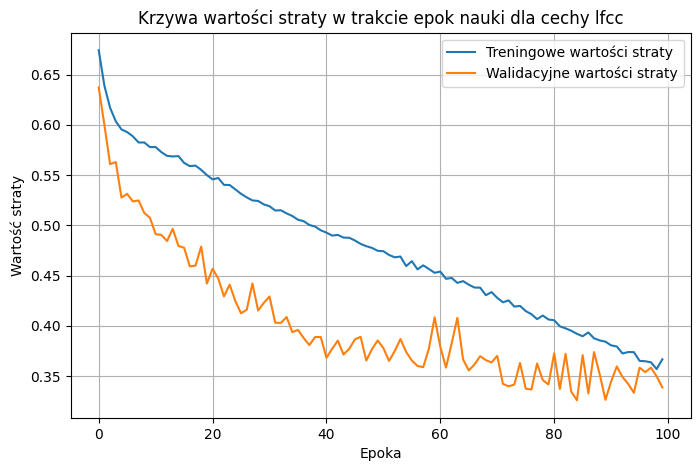

Final Accuracy: 0.8559 | F1 Score: 0.8503 | EER: 0.1430
Final Accuracy: 0.8578 | F1 Score: 0.8487 | EER: 0.1422
Zapisano modele i wyniki dla 'lfcc' → SGD_CrossEntropyLoss_lr0.001_mom0.95_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.001_mom0.95_wd0.0001\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla SGD_CrossEntropyLoss_lr0.001_mom0.95_wd0.0001 ==========


========== Trening z SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd1e-05 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6967 | Train Acc: 0.4954 | Val Loss: 0.6929 | Val Acc: 0.5000
[cqcc] Epoch 2/100 | Train Loss: 0.6953 | Train Acc: 0.5049 | Val Loss: 0.6921 | Val Acc: 0.5000
[cqcc] Epoch 3/100 | Train Loss: 0.6946 | Train Acc: 0.5056 | Val Loss: 0.6918 | Val Acc: 0.4989
[cqcc] Epoch 4/100 | Train Loss: 0.6950 | Train Acc: 0.5031 | Val Loss: 0.6910 | Val Acc: 0.5019
[cqcc] Epoch 5/100 | Train Loss: 0.6937 | Train Acc: 0.5080 | Val Loss: 0.6907 | Val Acc: 0.5004
[cqcc] Epoc

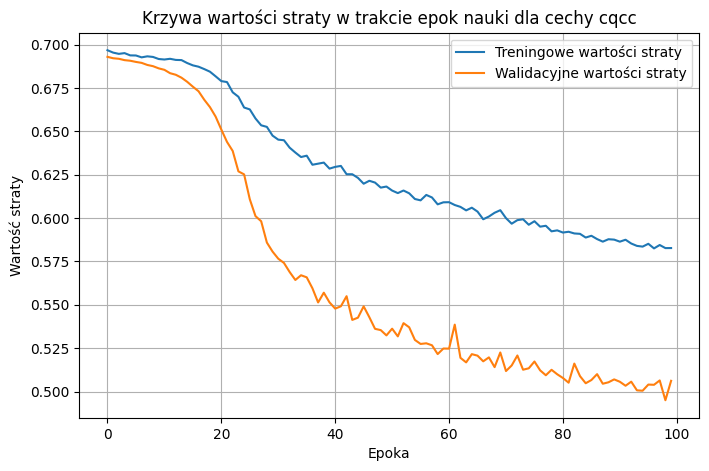

Final Accuracy: 0.7792 | F1 Score: 0.7632 | EER: 0.2197
Final Accuracy: 0.7769 | F1 Score: 0.7542 | EER: 0.2220
Zapisano modele i wyniki dla 'cqcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd1e-05\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6963 | Train Acc: 0.4989 | Val Loss: 0.6934 | Val Acc: 0.5000
[gtcc] Epoch 2/100 | Train Loss: 0.6964 | Train Acc: 0.4975 | Val Loss: 0.6929 | Val Acc: 0.5000
[gtcc] Epoch 3/100 | Train Loss: 0.6951 | Train Acc: 0.5071 | Val Loss: 0.6925 | Val Acc: 0.4989
[gtcc] Epoch 4/100 | Train Loss: 0.6968 | Train Acc: 0.5012 | Val Loss: 0.6923 | Val Acc: 0.6279
[gtcc] Epoch 5/100 | Train Loss: 0.6939 | Train Acc: 0.5206 | Val Loss: 0.6923 | Val Acc: 0.5090
[gtcc] Epoch 6/100 | Train Loss: 0.6946 | Train Acc: 0.5171 | Val Loss: 0.6917 | Val Acc: 0.5196
[gtcc] Epoch 7/100 | Train Loss: 0.6941 | Train Acc: 0.5227 | Val Loss: 0.6916 | Va

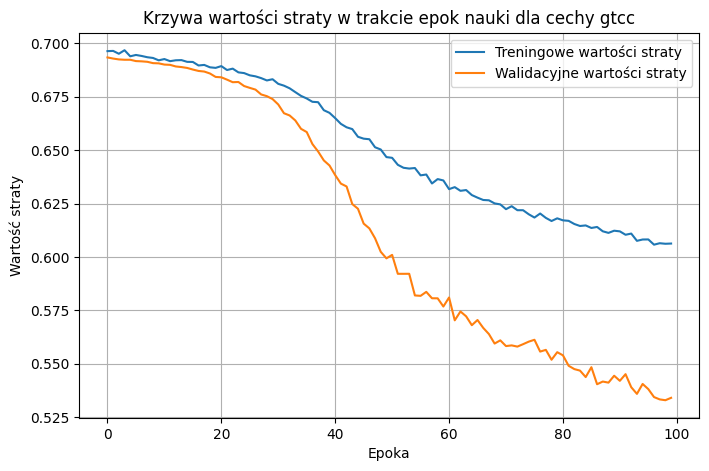

Final Accuracy: 0.7660 | F1 Score: 0.7371 | EER: 0.2498
Final Accuracy: 0.7675 | F1 Score: 0.7384 | EER: 0.2483
Zapisano modele i wyniki dla 'gtcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd1e-05\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6971 | Train Acc: 0.5131 | Val Loss: 0.6907 | Val Acc: 0.5576
[mel-spect] Epoch 2/100 | Train Loss: 0.6910 | Train Acc: 0.5197 | Val Loss: 0.6870 | Val Acc: 0.5933
[mel-spect] Epoch 3/100 | Train Loss: 0.6895 | Train Acc: 0.5309 | Val Loss: 0.6827 | Val Acc: 0.6114
[mel-spect] Epoch 4/100 | Train Loss: 0.6865 | Train Acc: 0.5466 | Val Loss: 0.6778 | Val Acc: 0.6238
[mel-spect] Epoch 5/100 | Train Loss: 0.6819 | Train Acc: 0.5607 | Val Loss: 0.6727 | Val Acc: 0.6422
[mel-spect] Epoch 6/100 | Train Loss: 0.6785 | Train Acc: 0.5675 | Val Loss: 0.6627 | Val Acc: 0.6509
[mel-spect] Epoch 7/100 | Train Loss: 0.6735 | T

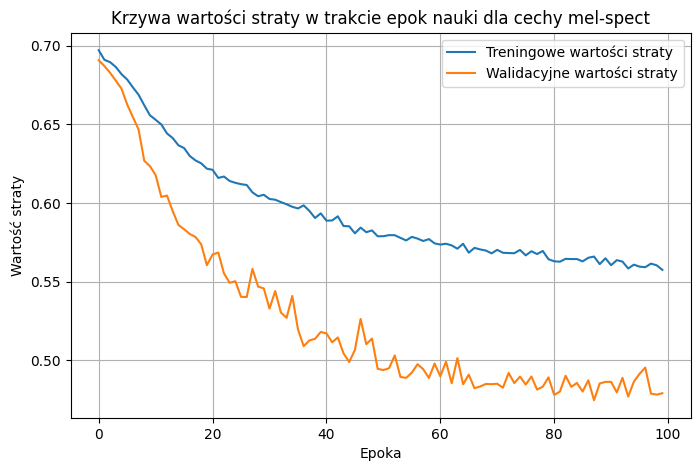

Final Accuracy: 0.7777 | F1 Score: 0.7420 | EER: 0.2062
Final Accuracy: 0.7720 | F1 Score: 0.7302 | EER: 0.2032
Zapisano modele i wyniki dla 'mel-spect' → SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd1e-05\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6966 | Train Acc: 0.4945 | Val Loss: 0.6853 | Val Acc: 0.5241
[mfcc] Epoch 2/100 | Train Loss: 0.6892 | Train Acc: 0.5261 | Val Loss: 0.6773 | Val Acc: 0.7607
[mfcc] Epoch 3/100 | Train Loss: 0.6822 | Train Acc: 0.5633 | Val Loss: 0.6691 | Val Acc: 0.7517
[mfcc] Epoch 4/100 | Train Loss: 0.6745 | Train Acc: 0.5928 | Val Loss: 0.6597 | Val Acc: 0.7299
[mfcc] Epoch 5/100 | Train Loss: 0.6671 | Train Acc: 0.6193 | Val Loss: 0.6499 | Val Acc: 0.7269
[mfcc] Epoch 6/100 | Train Loss: 0.6608 | Train Acc: 0.6324 | Val Loss: 0.6444 | Val Acc: 0.7092
[mfcc] Epoch 7/100 | Train Loss: 0.6550 | Train Acc: 0.6457 | Val Lo

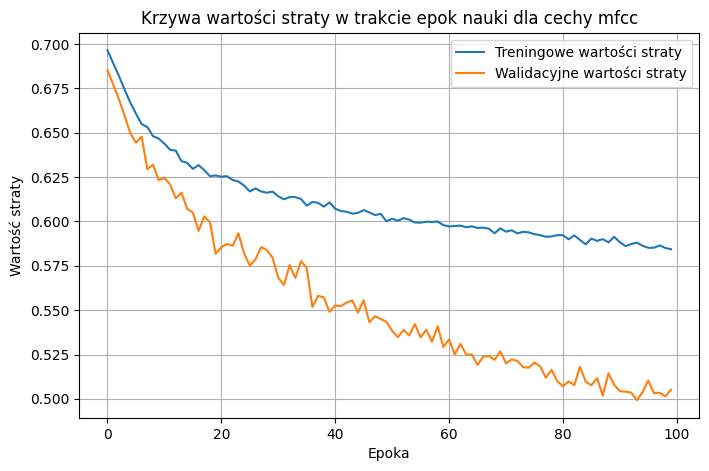

Final Accuracy: 0.7754 | F1 Score: 0.7760 | EER: 0.2257
Final Accuracy: 0.7716 | F1 Score: 0.7803 | EER: 0.2220
Zapisano modele i wyniki dla 'mfcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd1e-05\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6914 | Train Acc: 0.5031 | Val Loss: 0.6865 | Val Acc: 0.4992
[lfcc] Epoch 2/100 | Train Loss: 0.6867 | Train Acc: 0.5185 | Val Loss: 0.6827 | Val Acc: 0.6456
[lfcc] Epoch 3/100 | Train Loss: 0.6838 | Train Acc: 0.5335 | Val Loss: 0.6792 | Val Acc: 0.6738
[lfcc] Epoch 4/100 | Train Loss: 0.6824 | Train Acc: 0.5369 | Val Loss: 0.6797 | Val Acc: 0.6159
[lfcc] Epoch 5/100 | Train Loss: 0.6789 | Train Acc: 0.5510 | Val Loss: 0.6782 | Val Acc: 0.6053
[lfcc] Epoch 6/100 | Train Loss: 0.6773 | Train Acc: 0.5632 | Val Loss: 0.6715 | Val Acc: 0.6460
[lfcc] Epoch 7/100 | Train Loss: 0.6760 | Train Acc: 0.5630 | Val Loss: 0.6719 | Va

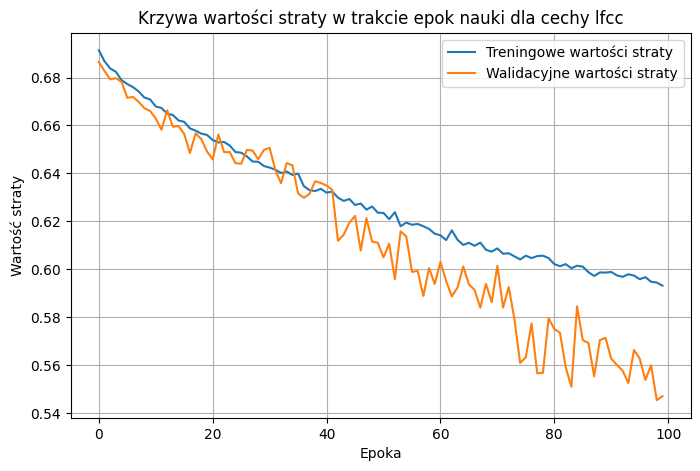

Final Accuracy: 0.7453 | F1 Score: 0.6944 | EER: 0.2295
Final Accuracy: 0.7445 | F1 Score: 0.6915 | EER: 0.2295
Zapisano modele i wyniki dla 'lfcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd1e-05\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd1e-05 ==========


========== Trening z SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd1e-05 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6941 | Train Acc: 0.5123 | Val Loss: 0.6912 | Val Acc: 0.5000
[cqcc] Epoch 2/100 | Train Loss: 0.6914 | Train Acc: 0.5218 | Val Loss: 0.6897 | Val Acc: 0.4996
[cqcc] Epoch 3/100 | Train Loss: 0.6886 | Train Acc: 0.5334 | Val Loss: 0.6857 | Val Acc: 0.5252
[cqcc] Epoch 4/100 | Train Loss: 0.6847 | Train Acc: 0.5514 | Val Loss: 0.6819 | Val Acc: 0.5647
[cqcc] Epoch 5/100 | Train Loss: 0.6804 | Train Acc: 0.5670 | Val Loss: 0.6709 | Val Acc: 0.6324
[cqcc] Epoch 

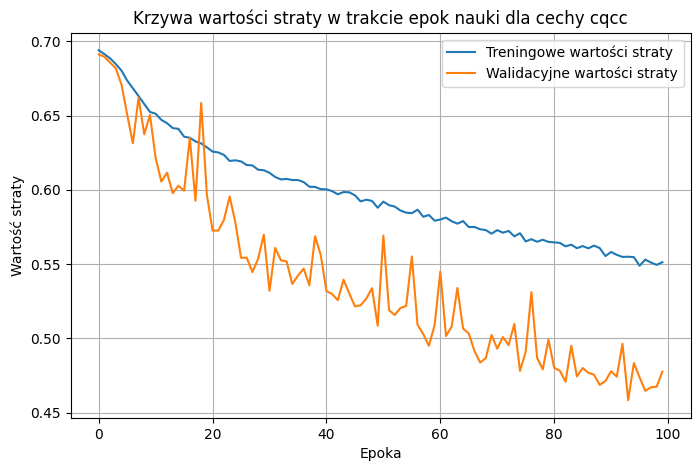

Final Accuracy: 0.8040 | F1 Score: 0.8003 | EER: 0.2009
Final Accuracy: 0.7931 | F1 Score: 0.8022 | EER: 0.1934
Zapisano modele i wyniki dla 'cqcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd1e-05\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6970 | Train Acc: 0.5019 | Val Loss: 0.6924 | Val Acc: 0.5226
[gtcc] Epoch 2/100 | Train Loss: 0.6954 | Train Acc: 0.5104 | Val Loss: 0.6919 | Val Acc: 0.5485
[gtcc] Epoch 3/100 | Train Loss: 0.6943 | Train Acc: 0.5145 | Val Loss: 0.6914 | Val Acc: 0.5173
[gtcc] Epoch 4/100 | Train Loss: 0.6941 | Train Acc: 0.5207 | Val Loss: 0.6911 | Val Acc: 0.5218
[gtcc] Epoch 5/100 | Train Loss: 0.6930 | Train Acc: 0.5314 | Val Loss: 0.6905 | Val Acc: 0.5184
[gtcc] Epoch 6/100 | Train Loss: 0.6927 | Train Acc: 0.5289 | Val Loss: 0.6899 | Val Acc: 0.5320
[gtcc] Epoch 7/100 | Train Loss: 0.6942 | Train Acc: 0.5266 | Val Loss: 0.6896 | 

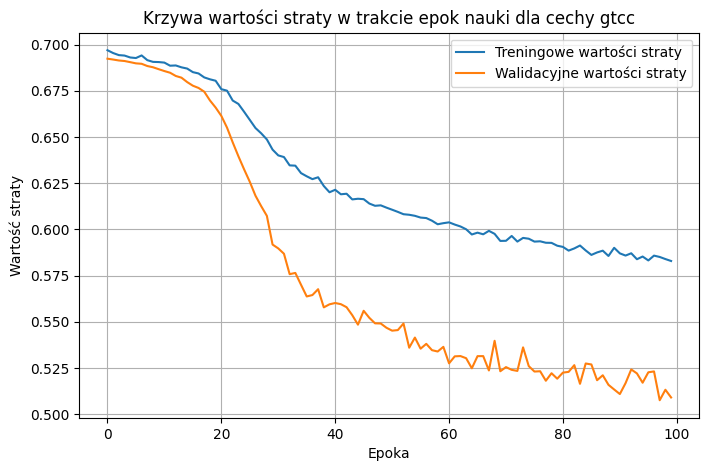

Final Accuracy: 0.7701 | F1 Score: 0.7374 | EER: 0.2205
Final Accuracy: 0.7679 | F1 Score: 0.7335 | EER: 0.2160
Zapisano modele i wyniki dla 'gtcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd1e-05\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6938 | Train Acc: 0.5108 | Val Loss: 0.6861 | Val Acc: 0.6283
[mel-spect] Epoch 2/100 | Train Loss: 0.6887 | Train Acc: 0.5320 | Val Loss: 0.6751 | Val Acc: 0.6682
[mel-spect] Epoch 3/100 | Train Loss: 0.6806 | Train Acc: 0.5627 | Val Loss: 0.6639 | Val Acc: 0.6674
[mel-spect] Epoch 4/100 | Train Loss: 0.6744 | Train Acc: 0.5730 | Val Loss: 0.6412 | Val Acc: 0.7129
[mel-spect] Epoch 5/100 | Train Loss: 0.6647 | Train Acc: 0.5961 | Val Loss: 0.6250 | Val Acc: 0.7171
[mel-spect] Epoch 6/100 | Train Loss: 0.6554 | Train Acc: 0.6071 | Val Loss: 0.5984 | Val Acc: 0.7611
[mel-spect] Epoch 7/100 | Train Loss: 0.6453 |

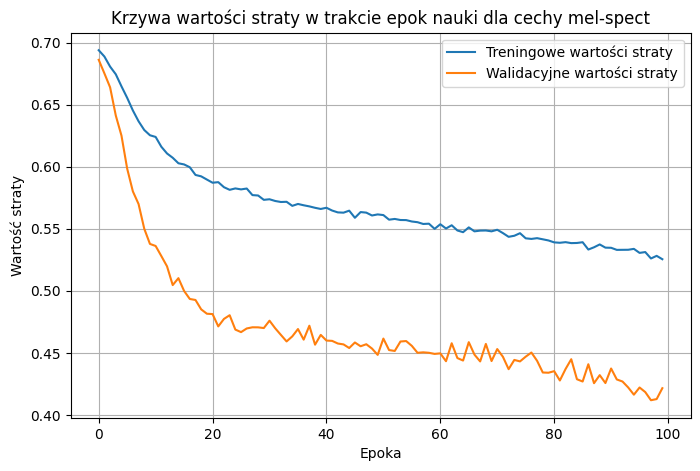

Final Accuracy: 0.8078 | F1 Score: 0.7872 | EER: 0.1836
Final Accuracy: 0.8047 | F1 Score: 0.7822 | EER: 0.1881
Zapisano modele i wyniki dla 'mel-spect' → SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd1e-05\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6943 | Train Acc: 0.5053 | Val Loss: 0.6852 | Val Acc: 0.5087
[mfcc] Epoch 2/100 | Train Loss: 0.6833 | Train Acc: 0.5537 | Val Loss: 0.6690 | Val Acc: 0.7641
[mfcc] Epoch 3/100 | Train Loss: 0.6716 | Train Acc: 0.6066 | Val Loss: 0.6523 | Val Acc: 0.7423
[mfcc] Epoch 4/100 | Train Loss: 0.6627 | Train Acc: 0.6283 | Val Loss: 0.6405 | Val Acc: 0.7077
[mfcc] Epoch 5/100 | Train Loss: 0.6542 | Train Acc: 0.6419 | Val Loss: 0.6343 | Val Acc: 0.6764
[mfcc] Epoch 6/100 | Train Loss: 0.6465 | Train Acc: 0.6482 | Val Loss: 0.6185 | Val Acc: 0.6979
[mfcc] Epoch 7/100 | Train Loss: 0.6404 | Train Acc: 0.6475 | Val 

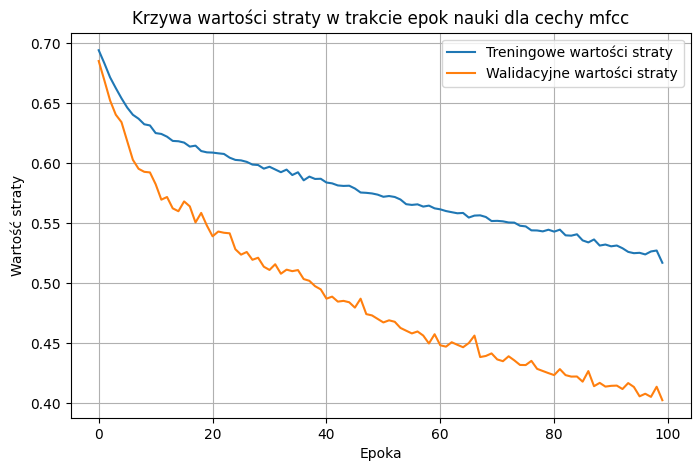

Final Accuracy: 0.8220 | F1 Score: 0.8110 | EER: 0.1881
Final Accuracy: 0.8220 | F1 Score: 0.8110 | EER: 0.1881
Zapisano modele i wyniki dla 'mfcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd1e-05\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6937 | Train Acc: 0.4987 | Val Loss: 0.6832 | Val Acc: 0.5128
[lfcc] Epoch 2/100 | Train Loss: 0.6866 | Train Acc: 0.5212 | Val Loss: 0.6771 | Val Acc: 0.6870
[lfcc] Epoch 3/100 | Train Loss: 0.6828 | Train Acc: 0.5435 | Val Loss: 0.6729 | Val Acc: 0.6599
[lfcc] Epoch 4/100 | Train Loss: 0.6796 | Train Acc: 0.5613 | Val Loss: 0.6714 | Val Acc: 0.6283
[lfcc] Epoch 5/100 | Train Loss: 0.6761 | Train Acc: 0.5703 | Val Loss: 0.6648 | Val Acc: 0.6565
[lfcc] Epoch 6/100 | Train Loss: 0.6716 | Train Acc: 0.5771 | Val Loss: 0.6673 | Val Acc: 0.6144
[lfcc] Epoch 7/100 | Train Loss: 0.6709 | Train Acc: 0.5812 | Val Loss: 0.6663 | 

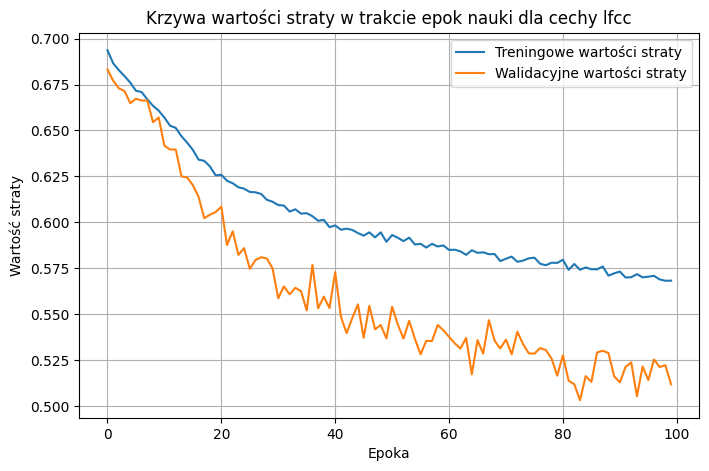

Final Accuracy: 0.7743 | F1 Score: 0.7425 | EER: 0.2002
Final Accuracy: 0.7667 | F1 Score: 0.7288 | EER: 0.1986
Zapisano modele i wyniki dla 'lfcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd1e-05
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd1e-05\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd1e-05 ==========


========== Trening z SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd0.0001 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6973 | Train Acc: 0.5000 | Val Loss: 0.6925 | Val Acc: 0.5256
[cqcc] Epoch 2/100 | Train Loss: 0.6950 | Train Acc: 0.5126 | Val Loss: 0.6920 | Val Acc: 0.6185
[cqcc] Epoch 3/100 | Train Loss: 0.6942 | Train Acc: 0.5151 | Val Loss: 0.6912 | Val Acc: 0.5775
[cqcc] Epoch 4/100 | Train Loss: 0.6937 | Train Acc: 0.5127 | Val Loss: 0.6904 | Val Acc: 0.7002
[cqcc] Epoch 5/100 | Train Loss: 0.6931 | Train Acc: 0.5199 | Val Loss: 0.6892 | Val Acc: 0.6746
[cqcc] Epo

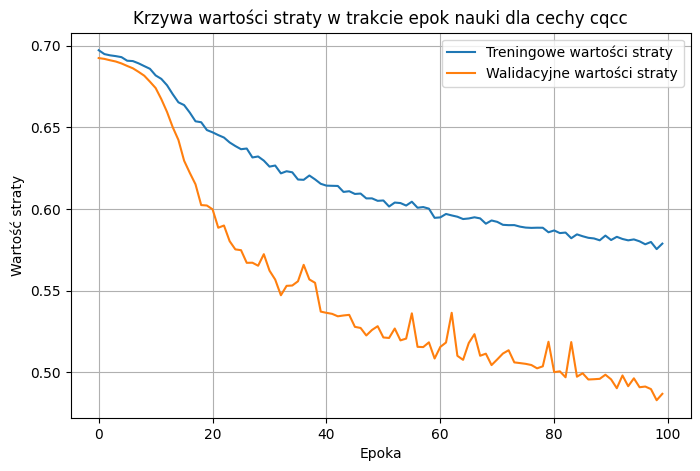

Final Accuracy: 0.7814 | F1 Score: 0.7761 | EER: 0.2167
Final Accuracy: 0.7795 | F1 Score: 0.7706 | EER: 0.2144
Zapisano modele i wyniki dla 'cqcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd0.0001\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6994 | Train Acc: 0.4938 | Val Loss: 0.6941 | Val Acc: 0.5000
[gtcc] Epoch 2/100 | Train Loss: 0.6973 | Train Acc: 0.4936 | Val Loss: 0.6929 | Val Acc: 0.5000
[gtcc] Epoch 3/100 | Train Loss: 0.6958 | Train Acc: 0.5023 | Val Loss: 0.6921 | Val Acc: 0.5000
[gtcc] Epoch 4/100 | Train Loss: 0.6964 | Train Acc: 0.5079 | Val Loss: 0.6915 | Val Acc: 0.5000
[gtcc] Epoch 5/100 | Train Loss: 0.6952 | Train Acc: 0.5124 | Val Loss: 0.6911 | Val Acc: 0.6230
[gtcc] Epoch 6/100 | Train Loss: 0.6941 | Train Acc: 0.5206 | Val Loss: 0.6905 | Val Acc: 0.6347
[gtcc] Epoch 7/100 | Train Loss: 0.6931 | Train Acc: 0.5287 | Val Loss: 0.6903 | 

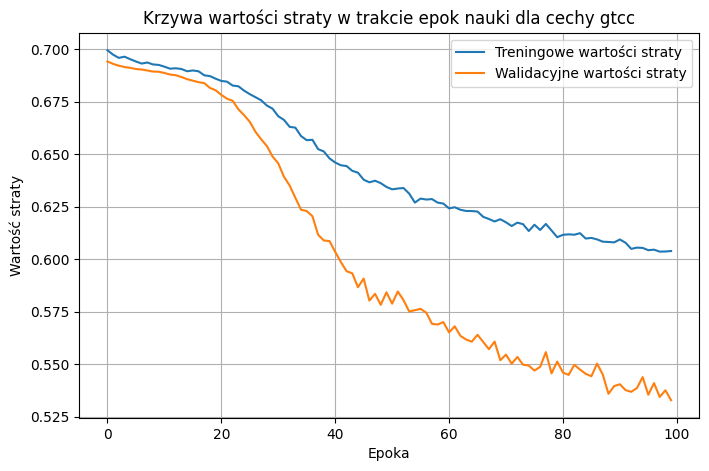

Final Accuracy: 0.7626 | F1 Score: 0.7300 | EER: 0.2491
Final Accuracy: 0.7626 | F1 Score: 0.7300 | EER: 0.2491
Zapisano modele i wyniki dla 'gtcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd0.0001\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6966 | Train Acc: 0.5025 | Val Loss: 0.6898 | Val Acc: 0.5470
[mel-spect] Epoch 2/100 | Train Loss: 0.6937 | Train Acc: 0.5180 | Val Loss: 0.6864 | Val Acc: 0.6561
[mel-spect] Epoch 3/100 | Train Loss: 0.6894 | Train Acc: 0.5279 | Val Loss: 0.6824 | Val Acc: 0.6971
[mel-spect] Epoch 4/100 | Train Loss: 0.6872 | Train Acc: 0.5406 | Val Loss: 0.6763 | Val Acc: 0.6960
[mel-spect] Epoch 5/100 | Train Loss: 0.6851 | Train Acc: 0.5493 | Val Loss: 0.6709 | Val Acc: 0.7144
[mel-spect] Epoch 6/100 | Train Loss: 0.6804 | Train Acc: 0.5646 | Val Loss: 0.6640 | Val Acc: 0.7385
[mel-spect] Epoch 7/100 | Train Loss: 0.6777 |

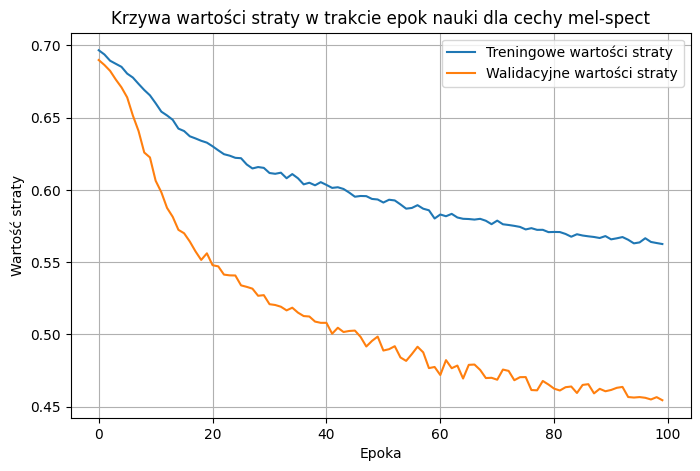

Final Accuracy: 0.7837 | F1 Score: 0.7675 | EER: 0.2167
Final Accuracy: 0.7837 | F1 Score: 0.7675 | EER: 0.2167
Zapisano modele i wyniki dla 'mel-spect' → SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd0.0001\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6896 | Train Acc: 0.5243 | Val Loss: 0.6829 | Val Acc: 0.7664
[mfcc] Epoch 2/100 | Train Loss: 0.6834 | Train Acc: 0.5535 | Val Loss: 0.6720 | Val Acc: 0.7517
[mfcc] Epoch 3/100 | Train Loss: 0.6768 | Train Acc: 0.5902 | Val Loss: 0.6641 | Val Acc: 0.7314
[mfcc] Epoch 4/100 | Train Loss: 0.6715 | Train Acc: 0.6101 | Val Loss: 0.6565 | Val Acc: 0.7235
[mfcc] Epoch 5/100 | Train Loss: 0.6669 | Train Acc: 0.6269 | Val Loss: 0.6493 | Val Acc: 0.7099
[mfcc] Epoch 6/100 | Train Loss: 0.6612 | Train Acc: 0.6396 | Val Loss: 0.6354 | Val Acc: 0.7329
[mfcc] Epoch 7/100 | Train Loss: 0.6574 | Train Acc: 0.6422 | Val 

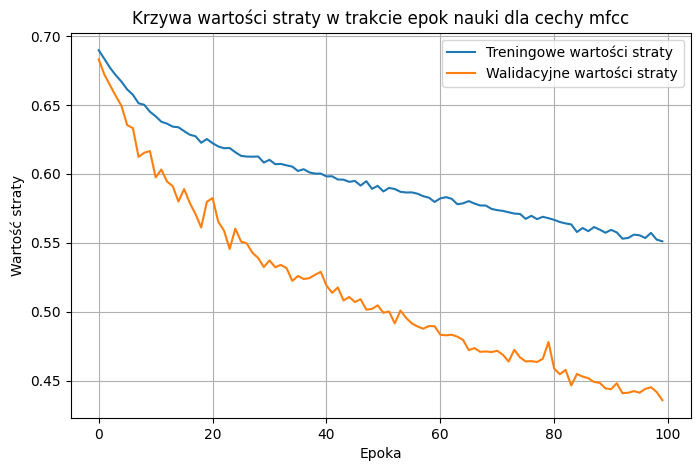

Final Accuracy: 0.8006 | F1 Score: 0.7897 | EER: 0.2099
Final Accuracy: 0.8006 | F1 Score: 0.7897 | EER: 0.2099
Zapisano modele i wyniki dla 'mfcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd0.0001\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6939 | Train Acc: 0.5082 | Val Loss: 0.6841 | Val Acc: 0.5004
[lfcc] Epoch 2/100 | Train Loss: 0.6867 | Train Acc: 0.5249 | Val Loss: 0.6815 | Val Acc: 0.6099
[lfcc] Epoch 3/100 | Train Loss: 0.6841 | Train Acc: 0.5341 | Val Loss: 0.6742 | Val Acc: 0.6934
[lfcc] Epoch 4/100 | Train Loss: 0.6829 | Train Acc: 0.5399 | Val Loss: 0.6763 | Val Acc: 0.6558
[lfcc] Epoch 5/100 | Train Loss: 0.6789 | Train Acc: 0.5520 | Val Loss: 0.6705 | Val Acc: 0.6795
[lfcc] Epoch 6/100 | Train Loss: 0.6784 | Train Acc: 0.5563 | Val Loss: 0.6670 | Val Acc: 0.6719
[lfcc] Epoch 7/100 | Train Loss: 0.6771 | Train Acc: 0.5611 | Val Loss: 0.6681 | 

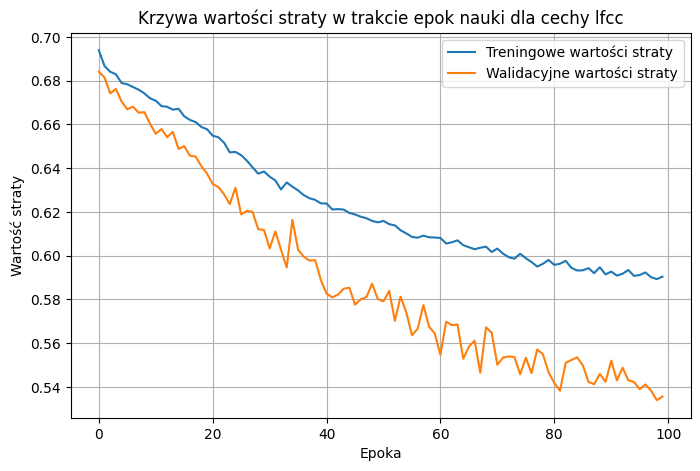

Final Accuracy: 0.7615 | F1 Score: 0.7231 | EER: 0.2137
Final Accuracy: 0.7600 | F1 Score: 0.7204 | EER: 0.2137
Zapisano modele i wyniki dla 'lfcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd0.0001\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla SGD_CrossEntropyLoss_lr0.0001_mom0.9_wd0.0001 ==========


========== Trening z SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd0.0001 ==========

=== TRENING dla cechy: cqcc ===
[cqcc] Epoch 1/100 | Train Loss: 0.6941 | Train Acc: 0.5088 | Val Loss: 0.6879 | Val Acc: 0.6159
[cqcc] Epoch 2/100 | Train Loss: 0.6926 | Train Acc: 0.5155 | Val Loss: 0.6852 | Val Acc: 0.6659
[cqcc] Epoch 3/100 | Train Loss: 0.6920 | Train Acc: 0.5156 | Val Loss: 0.6813 | Val Acc: 0.6911
[cqcc] Epoch 4/100 | Train Loss: 0.6890 | Train Acc: 0.5336 | Val Loss: 0.6782 | Val Acc: 0.6543
[cqcc] Epoch 5/100 | Train Loss: 0.6866 | Train Acc: 0.5446 | Val Loss: 0.6703 | Val Acc: 0.7024
[cqcc] Ep

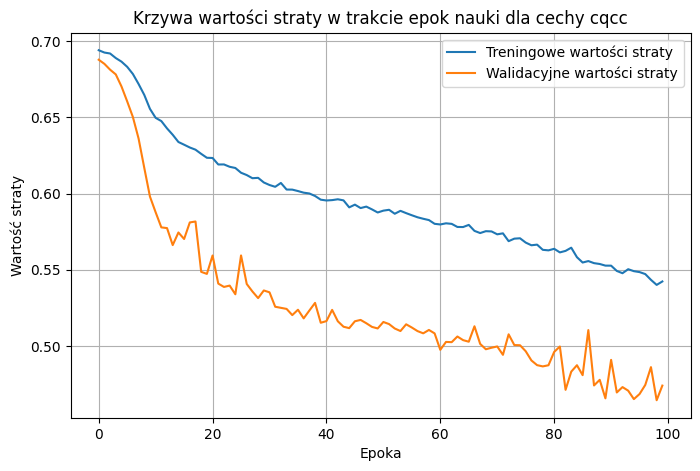

Final Accuracy: 0.7953 | F1 Score: 0.7677 | EER: 0.2017
Final Accuracy: 0.7931 | F1 Score: 0.7629 | EER: 0.2084
Zapisano modele i wyniki dla 'cqcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd0.0001\cqcc
=== KONIEC treningu dla cechy: cqcc ===


=== TRENING dla cechy: gtcc ===
[gtcc] Epoch 1/100 | Train Loss: 0.6965 | Train Acc: 0.5116 | Val Loss: 0.6913 | Val Acc: 0.5414
[gtcc] Epoch 2/100 | Train Loss: 0.6941 | Train Acc: 0.5281 | Val Loss: 0.6905 | Val Acc: 0.5260
[gtcc] Epoch 3/100 | Train Loss: 0.6934 | Train Acc: 0.5284 | Val Loss: 0.6902 | Val Acc: 0.5218
[gtcc] Epoch 4/100 | Train Loss: 0.6922 | Train Acc: 0.5381 | Val Loss: 0.6890 | Val Acc: 0.5301
[gtcc] Epoch 5/100 | Train Loss: 0.6909 | Train Acc: 0.5490 | Val Loss: 0.6879 | Val Acc: 0.5440
[gtcc] Epoch 6/100 | Train Loss: 0.6896 | Train Acc: 0.5558 | Val Loss: 0.6866 | Val Acc: 0.5553
[gtcc] Epoch 7/100 | Train Loss: 0.6898 | Train Acc: 0.5546 | Val Loss: 0.6853 

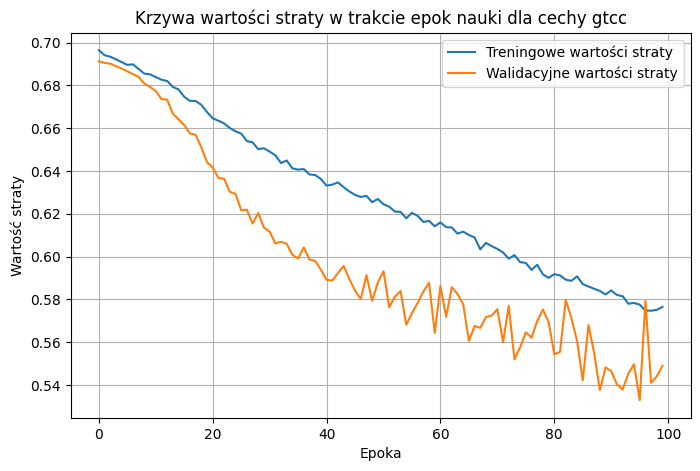

Final Accuracy: 0.7513 | F1 Score: 0.6989 | EER: 0.2167
Final Accuracy: 0.7351 | F1 Score: 0.6632 | EER: 0.2092
Zapisano modele i wyniki dla 'gtcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd0.0001\gtcc
=== KONIEC treningu dla cechy: gtcc ===


=== TRENING dla cechy: mel-spect ===
[mel-spect] Epoch 1/100 | Train Loss: 0.6961 | Train Acc: 0.5055 | Val Loss: 0.6907 | Val Acc: 0.5918
[mel-spect] Epoch 2/100 | Train Loss: 0.6887 | Train Acc: 0.5373 | Val Loss: 0.6828 | Val Acc: 0.6061
[mel-spect] Epoch 3/100 | Train Loss: 0.6812 | Train Acc: 0.5610 | Val Loss: 0.6699 | Val Acc: 0.6223
[mel-spect] Epoch 4/100 | Train Loss: 0.6717 | Train Acc: 0.5814 | Val Loss: 0.6527 | Val Acc: 0.6185
[mel-spect] Epoch 5/100 | Train Loss: 0.6603 | Train Acc: 0.6042 | Val Loss: 0.6268 | Val Acc: 0.6919
[mel-spect] Epoch 6/100 | Train Loss: 0.6518 | Train Acc: 0.6144 | Val Loss: 0.6107 | Val Acc: 0.6945
[mel-spect] Epoch 7/100 | Train Loss: 0.6421

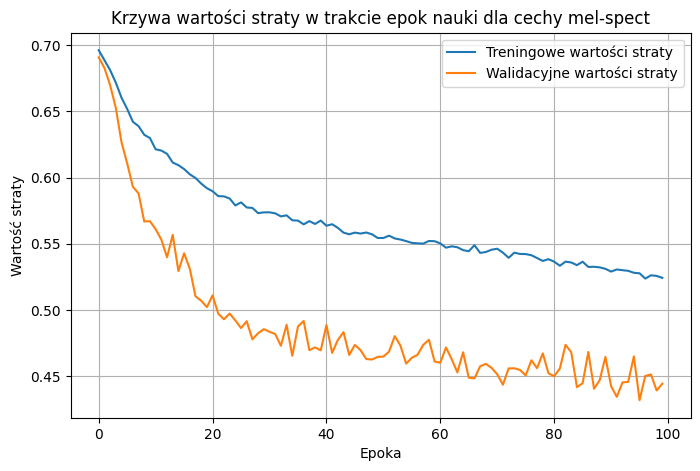

Final Accuracy: 0.8029 | F1 Score: 0.7753 | EER: 0.1934
Final Accuracy: 0.7998 | F1 Score: 0.7673 | EER: 0.1889
Zapisano modele i wyniki dla 'mel-spect' → SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd0.0001\mel-spect
=== KONIEC treningu dla cechy: mel-spect ===


=== TRENING dla cechy: mfcc ===
[mfcc] Epoch 1/100 | Train Loss: 0.6929 | Train Acc: 0.5090 | Val Loss: 0.6783 | Val Acc: 0.7114
[mfcc] Epoch 2/100 | Train Loss: 0.6790 | Train Acc: 0.5712 | Val Loss: 0.6550 | Val Acc: 0.7622
[mfcc] Epoch 3/100 | Train Loss: 0.6694 | Train Acc: 0.6062 | Val Loss: 0.6416 | Val Acc: 0.7419
[mfcc] Epoch 4/100 | Train Loss: 0.6577 | Train Acc: 0.6380 | Val Loss: 0.6197 | Val Acc: 0.7453
[mfcc] Epoch 5/100 | Train Loss: 0.6477 | Train Acc: 0.6429 | Val Loss: 0.6075 | Val Acc: 0.7269
[mfcc] Epoch 6/100 | Train Loss: 0.6409 | Train Acc: 0.6515 | Val Loss: 0.5888 | Val Acc: 0.7551
[mfcc] Epoch 7/100 | Train Loss: 0.6354 | Train Acc: 0.6500 | Va

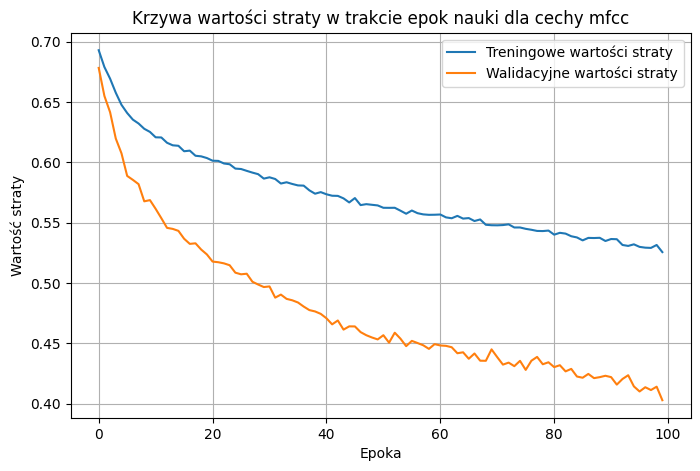

Final Accuracy: 0.8104 | F1 Score: 0.7910 | EER: 0.1971
Final Accuracy: 0.8104 | F1 Score: 0.7910 | EER: 0.1971
Zapisano modele i wyniki dla 'mfcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd0.0001\mfcc
=== KONIEC treningu dla cechy: mfcc ===


=== TRENING dla cechy: lfcc ===
[lfcc] Epoch 1/100 | Train Loss: 0.6898 | Train Acc: 0.5231 | Val Loss: 0.6813 | Val Acc: 0.6682
[lfcc] Epoch 2/100 | Train Loss: 0.6829 | Train Acc: 0.5422 | Val Loss: 0.6734 | Val Acc: 0.6591
[lfcc] Epoch 3/100 | Train Loss: 0.6780 | Train Acc: 0.5637 | Val Loss: 0.6631 | Val Acc: 0.6859
[lfcc] Epoch 4/100 | Train Loss: 0.6733 | Train Acc: 0.5742 | Val Loss: 0.6550 | Val Acc: 0.6889
[lfcc] Epoch 5/100 | Train Loss: 0.6694 | Train Acc: 0.5823 | Val Loss: 0.6494 | Val Acc: 0.6855
[lfcc] Epoch 6/100 | Train Loss: 0.6643 | Train Acc: 0.5959 | Val Loss: 0.6405 | Val Acc: 0.6986
[lfcc] Epoch 7/100 | Train Loss: 0.6588 | Train Acc: 0.6059 | Val Loss: 0.6300 

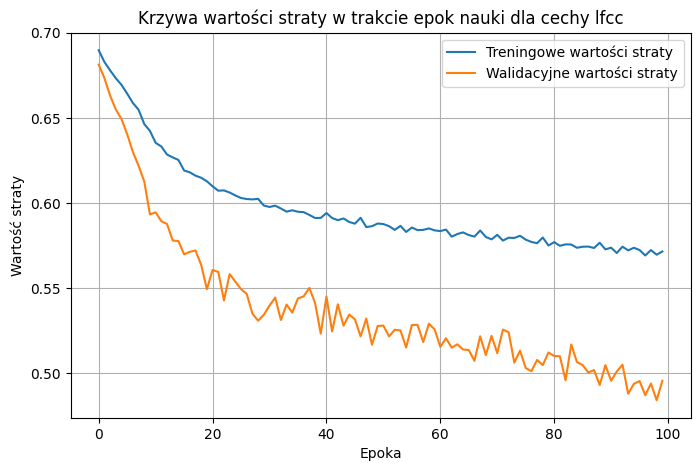

Final Accuracy: 0.7874 | F1 Score: 0.7633 | EER: 0.1986
Final Accuracy: 0.7825 | F1 Score: 0.7553 | EER: 0.2017
Zapisano modele i wyniki dla 'lfcc' → SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd0.0001
Folder: Res_Net\SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd0.0001\lfcc
=== KONIEC treningu dla cechy: lfcc ===

========== KONIEC treningu dla SGD_CrossEntropyLoss_lr0.0001_mom0.95_wd0.0001 ==========



In [ ]:
trained_models = train_all_features(train_df_noscale, feature_cols, epochs=100, label_col="label", test_df=val_df_noscale)